# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
from collections import defaultdict
from tqdm.notebook import trange, tqdm
from icecream import ic

import pandas as pd
import numpy as np
import scipy
import sklearn
import prince

import seaborn as sns
from matplotlib import pyplot as plt

from plotly import express as px
from plotly import graph_objects as go
import plotly.io as pio

In [3]:
from rsfp.metrics import *
from rsfp.constants import *
from rsfp.data import *
from rsfp.matching import *
from rsfp.dimensionality_reduction import *
from rsfp.utils import *

In [4]:
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 200)
pd.options.plotting.backend = "plotly"

# Data

## 2023

In [5]:
# load 2023 datasets
df_voters, df_candidates, df_questions = build_all(verbose=True)

Preprocessed voter DataFrame found.
Cleaned voter DataFrame found.
Cleaned candidate DataFrame found.


In [ ]:
# load uncleaned 2023 voter dataset
df_voters_all = build_voters(clean=False)
df_voters_all

In [6]:
# load recommendation data for L2 distance metric
df_voters = df_voters.load_candidate_voting_recommendations('df_voters_recommendations_spc_10_methods', selected_distance_methods=['L2_sv'])
df_candidates = df_candidates.load_candidate_recommendation_counts('df_candidates_recommendations_spc_10_methods', selected_distance_methods=['L2_sv'])

In [ ]:
# load list recommendations for L2 distance metric
df_voters = df_voters.load_list_voting_recommendations('df_voters_list_recommendations_10_methods', selected_distance_methods=['L2_sv'])

In [276]:
# load recommendation data for evaluated distance metrics
df_voters = df_voters.load_candidate_voting_recommendations('df_voters_recommendations_spc_10_methods', selected_distance_methods=EVAL_DISTANCE_METHODS)
df_candidates = df_candidates.load_candidate_recommendation_counts('df_candidates_recommendations_spc_10_methods', selected_distance_methods=EVAL_DISTANCE_METHODS)

In [ ]:
# load list recommendations for evaluated distance metrics
df_voters = df_voters.load_list_voting_recommendations('df_voters_list_recommendations_10_methods', selected_distance_methods=EVAL_DISTANCE_METHODS)

In [14]:
# add dimensionality reduction columns
df_candidates, obj = add_pca_cols(df_candidates, n_dims=2, return_obj=True)
df_voters = add_pca_cols(df_voters, n_dims=2, obj=obj)

df_candidates, obj = add_ca_cols(df_candidates, n_dims=2, return_obj=True)
df_voters = add_ca_cols(df_voters, n_dims=2, obj=obj)

df_candidates, obj = add_tsvd_cols(df_candidates, n_dims=2, return_obj=True)
df_voters = add_tsvd_cols(df_voters, n_dims=2, obj=obj)

In [ ]:
# plot PCA distribution of candidates
fig = px.scatter(df_candidates[~df_candidates['_party'].isin(['Parteilos', 'Andere'])], x='PCA_0', y='-PCA_1', color='_party', color_discrete_map=PARTY2COLOR)
fig.update_layout(
    xaxis_title='Left - Right',
    yaxis_title='Conservative - Liberal',
    legend=dict(
        title='Party',
        x=1,
        y=1,
        xanchor='left',
        yanchor='top',
        itemsizing='constant',
    )
).update_traces(marker_size=3)


## 2019

In [62]:
# load 2019 datasets
df_voters19, df_candidates19, df_questions19 = build_all19(verbose=True)

No cleaned voter19 DataFrame found. Cleaning starts now.
No cleaned candidate19 DataFrame found. Cleaning starts now.


In [ ]:
# load uncleaned 2019 voter dataset
df_voters19_all = build_voters19(clean=False)

In [6]:
# load recommendation data for L2 distance metric
df_voters19 = df_voters19.load_candidate_voting_recommendations('df_voters19_recommendations_spc_10_methods', selected_distance_methods=['L2_sv'])
df_candidates19 = df_candidates19.load_candidate_recommendation_counts('df_candidates19_recommendations_spc_10_methods', selected_distance_methods=['L2_sv'])

In [ ]:
# load list recommendations for L2 distance metric
df_voters19 = df_voters19.load_list_voting_recommendations('df_voters19_list_recommendations_10_methods', selected_distance_methods=['L2_sv'])

In [276]:
# load recommendation data for evaluated distance metrics
df_voters19 = df_voters19.load_candidate_voting_recommendations('df_voters19_recommendations_spc_10_methods', selected_distance_methods=EVAL_DISTANCE_METHODS)
df_candidates19 = df_candidates19.load_candidate_recommendation_counts('df_candidates19_recommendations_spc_10_methods', selected_distance_methods=EVAL_DISTANCE_METHODS)

In [ ]:
# load list recommendations for evaluated distance metrics
df_voters19 = df_voters19.load_list_voting_recommendations('df_voters19_list_recommendations_10_methods', selected_distance_methods=EVAL_DISTANCE_METHODS)

In [ ]:
# add dimensionality reduction columns
df_candidates19, obj = add_pca_cols(df_candidates19, n_dims=2, return_obj=True)
df_voters19 = add_pca_cols(df_voters19, n_dims=2, obj=obj)

df_candidates19, obj = add_ca_cols(df_candidates19, n_dims=2, return_obj=True)
df_voters19 = add_ca_cols(df_voters19, n_dims=2, obj=obj)

df_candidates19, obj = add_tsvd_cols(df_candidates19, n_dims=2, return_obj=True)
df_voters19 = add_tsvd_cols(df_voters19, n_dims=2, obj=obj)

# Answer Calibration (AC + CP)

## Neutral Answers (CP-M)

In [7]:
# HELPER FUNCTIONS

def map_to_closest_old(array_2d, specified_numbers):
    # Expand dimensions to perform broadcasting
    array_expanded = np.expand_dims(array_2d, axis=-1)  # Shape (m, n, 1)
    specified_expanded = np.expand_dims(specified_numbers, axis=(0, 1))  # Shape (1, 1, k)
    
    # Calculate the absolute differences between array elements and specified numbers
    differences = np.abs(array_expanded - specified_expanded)  # Shape (m, n, k)
    
    # Find the index of the minimum difference
    closest_indices = np.argmin(differences, axis=-1)  # Shape (m, n)
    
    # Map to the closest number
    mapped_array = specified_numbers[closest_indices]  # Shape (m, n)
    
    return mapped_array


def map_to_closest(array_2d, specified_numbers):
    # Create an array to store the result
    mapped_array = np.full(array_2d.shape, np.nan)

    # Find non-NaN elements
    non_nan_mask = ~np.isnan(array_2d)
    
    # Expand dimensions to perform broadcasting for non-NaN elements
    array_expanded = np.expand_dims(array_2d[non_nan_mask], axis=-1)  # Shape (p, 1)
    specified_expanded = np.expand_dims(specified_numbers, axis=0)  # Shape (1, k)
    
    # Calculate the absolute differences between array elements and specified numbers
    differences = np.abs(array_expanded - specified_expanded)  # Shape (p, k)
    
    # Find the index of the minimum difference
    closest_indices = np.argmin(differences, axis=-1)  # Shape (p,)
    
    # Map to the closest number
    mapped_array[non_nan_mask] = specified_numbers[closest_indices]  # Shape (m, n)
    
    return mapped_array


def map_to_answer_possibilites(answer_matrix):
    assert answer_matrix.shape[1] == 75, "answer matrix has to have 75 columns corresponding to the 75 questions in 2023 questionnaire"
    
    answer_matrix[:, :60] = map_to_closest(answer_matrix[:, :60], np.array([0, 25, 75, 100]))
    answer_matrix[:, 60:67] = map_to_closest(answer_matrix[:, 60:67], np.array([0, 17, 33, 50, 67, 83, 100]))
    answer_matrix[:, 67:] = map_to_closest(answer_matrix[:, 67:], np.array([0, 25, 50, 75, 100]))

    return answer_matrix
    


def get_simulated_gaussian_sample(df_candidates_or_voters: pd.DataFrame, size=1000, map_to_answer_possibilities: bool = True, seed: int = 0):
    empirical_mean = df_candidates_or_voters.a().mean().to_numpy()
    empirical_cov = np.cov(df_candidates_or_voters.a(), rowvar=False)

    rng = np.random.default_rng(seed=seed)
    sample = rng.multivariate_normal(mean=empirical_mean, cov=empirical_cov, size=size)

    if map_to_answer_possibilities:
        sample = map_to_answer_possibilites(sample)

    return sample

In [58]:
# COMPUTE WHAT-IF ANALYSIS (ALL CANDIDATES OF A PARTY EMPLOY MODERATE ANSWERING STRATEGY)

method_dfs = {
    
}

for method in tqdm([m for m in EVAL_DISTANCE_METHODS if m!='L2_sv']):
    ic(method)
    method_dfs[method] = {
        'candidates': {},
    }
    for party in tqdm(df_candidates['_party'].unique()):
        ic(party)
        df_candidates_modified = df_candidates.copy()
        df_voters_recommendations = df_voters.copy()
        candidate_party_mask = df_candidates_modified['_party'] == party
    
        # minimize answer strengths of all candidates in party
        df_candidates_modified.loc[candidate_party_mask, get_cols(df_candidates_modified)] = map_to_answer_possibilites(((df_candidates_modified[candidate_party_mask].a().to_numpy() - 50)*0.01)+50)
    
        # update answer strength stats
        df_candidates_modified.loc[candidate_party_mask, '_answer_strength'] = (df_candidates_modified[candidate_party_mask][get_cols(df_candidates_modified)] - 50).abs().mean(axis=1)
        df_candidates_modified.loc[candidate_party_mask, '_answer_strength_std'] = (df_candidates_modified[candidate_party_mask][get_cols(df_candidates_modified)] - 50).abs().std(axis=1)
    
        # calculate what if recommendations
        df_voters_recommendations = add_candidate_voting_recommendations(df_voters_recommendations, df_candidates_modified, distance_method=method)
    
        df_candidates_modified.add_recommendation_counts(df_voters_recommendations)
    
        ic(df_candidates_modified.columns[-5:])
    
        # store results
        method_dfs[method]['candidates'][party] = df_candidates_modified

    filename = 'data/cache/what_if_analysis_all_party_dfs_eval_methods_sv_tiebreaking_recommendations.pkl'
    with open(filename, 'wb') as file:
        # Serialize the dictionary and write it to the file
        pickle.dump(method_dfs, file)

  0%|          | 0/6 [00:00<?, ?it/s]

ic| method: 'L1'


  0%|          | 0/13 [00:00<?, ?it/s]

ic| party: 'Grüne'


  0%|          | 0/26 [00:00<?, ?it/s]

...

  0%|          | 0/892 [00:00<?, ?it/s]

  0%|          | 0/353 [00:00<?, ?it/s]

  0%|          | 0/806 [00:00<?, ?it/s]

  0%|          | 0/662 [00:00<?, ?it/s]

ic| df_candidates_modified.columns[-5:]: Index(['_n_recommendations_top_DM_HYBRID',
                                                '_n_recommendations_spc_L2_sv_normalized',
                                                '_n_recommendations_top_L2_sv_normalized',
                                                '_n_recommendations_spc_DM_HYBRID_normalized',
                                                '_n_recommendations_top_DM_HYBRID_normalized'],
                                               dtype='object')


In [8]:
# LOAD
import pickle

filename = 'data/cache/what_if_analysis_all_party_dfs_eval_methods_sv_tiebreaking_recommendations.pkl'
with open(filename, 'rb') as file:
    # Serialize the dictionary and write it to the file
    method_dfs = pickle.load(file)

In [79]:
# SAVE

filename = 'data/cache/what_if_analysis_all_party_dfs_eval_methods_sv_tiebreaking_recommendations.pkl'
with open(filename, 'wb') as file:
    # Serialize the dictionary and write it to the file
    pickle.dump(method_dfs, file)

In [9]:
# load smartvote recommendation counts
df_candidates = df_candidates.load_candidate_recommendation_counts('df_candidates_recommendations_spc_10_methods', selected_distance_methods=EVAL_DISTANCE_METHODS)

In [16]:
# ANALYZE

#party_col = 'party_short'
#unique_parties = df_candidates[party_col].unique()

#party_col, unique_parties = '_party', BIG_PARTIES

party_col, unique_parties = '_party', df_candidates['_party'].unique()

dfs_analysis = []
for method in method_dfs:
    manipulated_strengths = []
    for party in unique_parties:
        print(party)
        manipulated_strengths.append(method_dfs[method]['candidates'][party].get_party_visibilities(party_col=party_col).loc[party, f'Party Visibility ({method})'])

    df_party_strengths = df_candidates.get_party_visibilities(party_col=party_col)
    df_analysis = df_party_strengths[f'Party Visibility ({method})'].to_frame().join(pd.DataFrame(index=unique_parties, data=manipulated_strengths, columns=[f'Manipulated ({method})'])).rename(columns={f'Party Visibility ({method})': f'Actual ({method})'})
    dfs_analysis.append(df_analysis)

df_analysis = pd.concat(dfs_analysis, axis=1)
df_analysis

Green
Parteilos
MCG
GLP
Centre
FDP
EVP
SP
Andere
PdA
SVP
EDU
Lega
Green
Parteilos
MCG
GLP
Centre
FDP
EVP
SP
Andere
PdA
SVP
EDU
Lega
Green
Parteilos
MCG
GLP
Centre
FDP
EVP
SP
Andere
PdA
SVP
EDU
Lega
Green
Parteilos
MCG
GLP
Centre
FDP
EVP
SP
Andere
PdA
SVP
EDU
Lega
Green
Parteilos
MCG
GLP
Centre
FDP
EVP
SP
Andere
PdA
SVP
EDU
Lega
Green
Parteilos
MCG
GLP
Centre
FDP
EVP
SP
Andere
PdA
SVP
EDU
Lega
Green
Parteilos
MCG
GLP
Centre
FDP
EVP
SP
Andere
PdA
SVP
EDU
Lega


,Actual (L1),Manipulated (L1),Actual (AC),Manipulated (AC),Actual (angular),Manipulated (angular),Actual (mahalanobis_unweighted),Manipulated (mahalanobis_unweighted),Actual (DM_L1_BONUS),Manipulated (DM_L1_BONUS),Actual (DM_HYBRID),Manipulated (DM_HYBRID),Actual (L2_sv),Manipulated (L2_sv)
_party,,,,,,,,,,,,,,
Andere,0.068634,0.131404,0.076723,0.059122,0.067122,0.052388,0.046752,0.240044,0.074424,0.014687,0.067417,0.033337,0.073464,0.280596
Centre,0.196895,0.270684,0.160995,0.126213,0.158310,0.131212,0.147020,0.425490,0.130583,0.042350,0.158184,0.104974,0.218844,0.464951
EDU,0.027791,0.052921,0.027217,0.023315,0.026969,0.022444,0.014318,0.087471,0.025580,0.006095,0.026244,0.015175,0.028473,0.119013
EVP,0.074691,0.144083,0.060690,0.071054,0.064592,0.050703,0.053968,0.227959,0.048707,0.018617,0.059966,0.038433,0.084871,0.284643
FDP,0.078578,0.140711,0.077889,0.065013,0.081963,0.067606,0.053699,0.294329,0.080764,0.018535,0.080737,0.048192,0.079726,0.273066
GLP,0.141973,0.211356,0.129672,0.107103,0.119243,0.084619,0.157521,0.497766,0.098981,0.026072,0.114439,0.056537,0.150703,0.393609
Green,0.142125,0.181970,0.165375,0.085940,0.172944,0.089127,0.232599,0.604863,0.200888,0.019477,0.182498,0.034586,0.122854,0.389226
Lega,0.000649,0.001065,0.000602,0.000540,0.000681,0.000539,0.000423,0.001978,0.000654,0.000156,0.000682,0.000338,0.000599,0.002292
MCG,0.001645,0.003400,0.001888,0.001458,0.001889,0.001609,0.000540,0.004117,0.002124,0.000474,0.001880,0.001290,0.001414,0.006260


In [14]:
df_candidates = df_candidates.add_n_votes()

df_candidates.get_party_visibilities()

,Party Visibility (L2_sv),Party Visibility (L1),Party Visibility (AC),Party Visibility (angular),Party Visibility (mahalanobis_unweighted),Party Visibility (DM_L1_BONUS),Party Visibility (DM_HYBRID),Party Visibility (Actual Votes)
_party,,,,,,,,
Andere,0.073464,0.068634,0.076723,0.067122,0.046752,0.074424,0.067417,0.022769
Centre,0.218844,0.196895,0.160995,0.158310,0.147020,0.130583,0.158184,0.146591
EDU,0.028473,0.027791,0.027217,0.026969,0.014318,0.025580,0.026244,0.011307
EVP,0.084871,0.074691,0.060690,0.064592,0.053968,0.048707,0.059966,0.019940
FDP,0.079726,0.078578,0.077889,0.081963,0.053699,0.080764,0.080737,0.138143
GLP,0.150703,0.141973,0.129672,0.119243,0.157521,0.098981,0.114439,0.080449
Green,0.122854,0.142125,0.165375,0.172944,0.232599,0.200888,0.182498,0.104057
Lega,0.000599,0.000649,0.000602,0.000681,0.000423,0.000654,0.000682,0.002239
MCG,0.001414,0.001645,0.001888,0.001889,0.000540,0.002124,0.001880,0.003296


In [18]:
for method in np.unique([c.split('(')[1].split(')')[0] for c in df_analysis.columns if '(' in c]):
    df_analysis[f'Ratio ({method})'] = ((df_analysis[f'Manipulated ({method})'] / df_analysis[f'Actual ({method})']))
    df_analysis[f'Gain ({method})'] = ((df_analysis[f'Manipulated ({method})'] - df_analysis[f'Actual ({method})']))

In [29]:
df_analysis['Party Visibility'] = df_analysis.index.map(df_candidates.get_party_visibilities()['Party Visibility (Actual Votes)'].to_dict())

df_analysis_parties = df_analysis.drop(labels=['Andere', 'Parteilos'])
df_analysis_parties

,Actual (L1),Manipulated (L1),Actual (AC),Manipulated (AC),Actual (angular),Manipulated (angular),Actual (mahalanobis_unweighted),Manipulated (mahalanobis_unweighted),Actual (DM_L1_BONUS),Manipulated (DM_L1_BONUS),Actual (DM_HYBRID),Manipulated (DM_HYBRID),Actual (L2_sv),Manipulated (L2_sv),Ratio (AC),Gain (AC),Ratio (DM_HYBRID),Gain (DM_HYBRID),Ratio (DM_L1_BONUS),Gain (DM_L1_BONUS),Ratio (L1),Gain (L1),Ratio (L2_sv),Gain (L2_sv),Ratio (angular),Gain (angular),Ratio (mahalanobis_unweighted),Gain (mahalanobis_unweighted),Party Visibility
_party,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Centre,0.196895,0.270684,0.160995,0.126213,0.158310,0.131212,0.147020,0.425490,0.130583,0.042350,0.158184,0.104974,0.218844,0.464951,0.783956,-0.034782,0.663617,-0.053211,0.324312,-0.088233,1.374767,0.073790,2.124577,0.246107,0.828829,-0.027098,2.894094,0.278470,0.146591
EDU,0.027791,0.052921,0.027217,0.023315,0.026969,0.022444,0.014318,0.087471,0.025580,0.006095,0.026244,0.015175,0.028473,0.119013,0.856626,-0.003902,0.578235,-0.011069,0.238286,-0.019485,1.904294,0.025131,4.179841,0.090540,0.832210,-0.004525,6.109372,0.073154,0.011307
EVP,0.074691,0.144083,0.060690,0.071054,0.064592,0.050703,0.053968,0.227959,0.048707,0.018617,0.059966,0.038433,0.084871,0.284643,1.170770,0.010364,0.640916,-0.021533,0.382219,-0.030090,1.929041,0.069391,3.353811,0.199771,0.784963,-0.013890,4.224001,0.173992,0.019940
FDP,0.078578,0.140711,0.077889,0.065013,0.081963,0.067606,0.053699,0.294329,0.080764,0.018535,0.080737,0.048192,0.079726,0.273066,0.834685,-0.012876,0.596905,-0.032545,0.229502,-0.062228,1.790723,0.062133,3.425057,0.193340,0.824830,-0.014357,5.481081,0.240630,0.138143
GLP,0.141973,0.211356,0.129672,0.107103,0.119243,0.084619,0.157521,0.497766,0.098981,0.026072,0.114439,0.056537,0.150703,0.393609,0.825946,-0.022570,0.494039,-0.057902,0.263408,-0.072908,1.488706,0.069383,2.611815,0.242906,0.709642,-0.034623,3.159998,0.340245,0.080449
Green,0.142125,0.181970,0.165375,0.085940,0.172944,0.089127,0.232599,0.604863,0.200888,0.019477,0.182498,0.034586,0.122854,0.389226,0.519665,-0.079436,0.189515,-0.147912,0.096955,-0.181411,1.280356,0.039846,3.168191,0.266372,0.515350,-0.083817,2.600450,0.372264,0.104057
Lega,0.000649,0.001065,0.000602,0.000540,0.000681,0.000539,0.000423,0.001978,0.000654,0.000156,0.000682,0.000338,0.000599,0.002292,0.897348,-0.000062,0.495094,-0.000344,0.238095,-0.000498,1.641951,0.000417,3.826460,0.001693,0.791682,-0.000142,4.673556,0.001555,0.002239
MCG,0.001645,0.003400,0.001888,0.001458,0.001889,0.001609,0.000540,0.004117,0.002124,0.000474,0.001880,0.001290,0.001414,0.006260,0.772096,-0.000430,0.686314,-0.000590,0.223407,-0.001649,2.067473,0.001756,4.427757,0.004846,0.851838,-0.000280,7.617899,0.003577,0.003296
PdA,0.008320,0.029967,0.009522,0.015796,0.011951,0.007459,0.005848,0.049269,0.011749,0.003337,0.011159,0.005454,0.006876,0.063869,1.658940,0.006274,0.488734,-0.005705,0.284054,-0.008411,3.602039,0.021648,9.288684,0.056993,0.624177,-0.004491,8.425623,0.043422,0.004245


In [33]:
(df_analysis_parties[[c for c in df_analysis.columns if c.startswith('Ratio')]] * df_analysis_parties['Party Visibility'].to_numpy().reshape(-1, 1)).sum() / df_analysis_parties['Party Visibility'].sum()

Ratio (AC)                        0.637996
Ratio (DM_HYBRID)                 0.451771
Ratio (DM_L1_BONUS)               0.186067
Ratio (L1)                        1.455630
Ratio (L2_sv)                     3.066399
Ratio (angular)                   0.732982
Ratio (mahalanobis_unweighted)    4.058680
dtype: float64

### Metric (CP-M)

In [34]:
# CP-M

(df_analysis_parties[[c for c in df_analysis_parties.columns if c.startswith('Ratio')]] * df_analysis_parties['Party Visibility'].to_numpy().reshape(-1, 1)).sum() / df_analysis_parties['Party Visibility'].sum() - 1

Ratio (AC)                       -0.362004
Ratio (DM_HYBRID)                -0.548229
Ratio (DM_L1_BONUS)              -0.813933
Ratio (L1)                        0.455630
Ratio (L2_sv)                     2.066399
Ratio (angular)                  -0.267018
Ratio (mahalanobis_unweighted)    3.058680
dtype: float64

### Plot

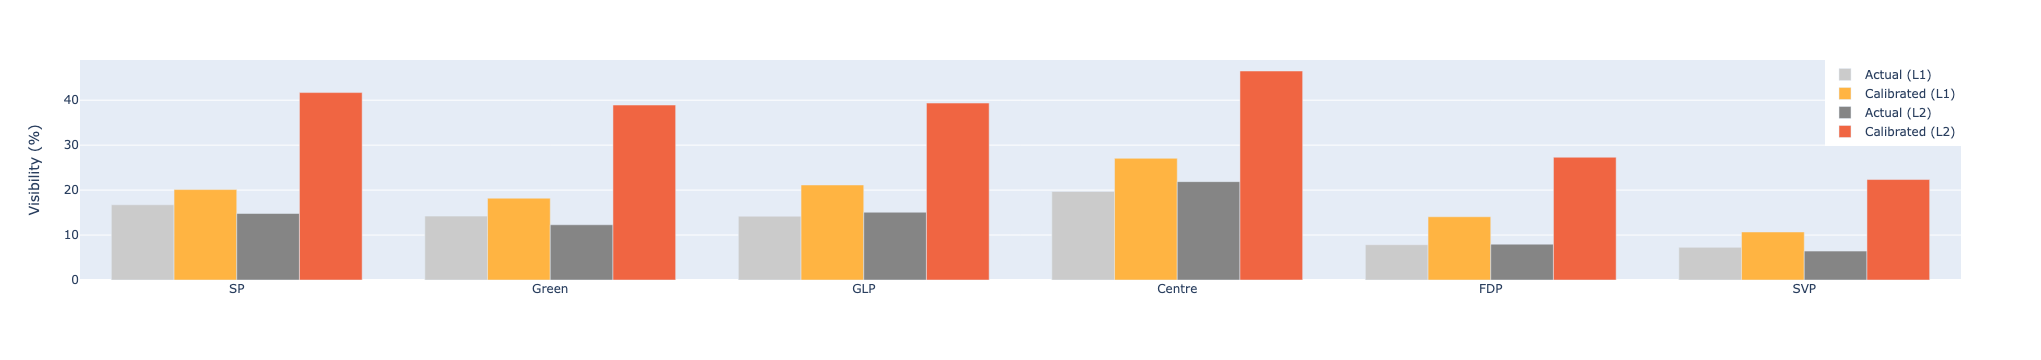

In [84]:
# VISUALIZE
method = 'L1'
methods = ['L1', 'L2_sv']

#custom_colors = ['#b3b3b3', '#ffcc80', '#ff9900']
custom_colors = ['#cbcbcb','#ffb442', '#858585', '#f06542']

fig = px.bar(100*df_analysis.loc[BIG_PARTIES, [i for method in methods for i in [f'Actual ({method})', f'Manipulated ({method})']]], barmode='group', color_discrete_sequence=custom_colors)

trace_name_map = {
    'Actual (L2_sv)': 'Actual (L2)', 
    'Manipulated (L2_sv)': 'Calibrated (L2)',
    'Manipulated (L1)': 'Calibrated (L1)',
    'Manipulated (angular)': 'Calibrated (Angular)',
}

fig.for_each_trace(lambda trace: trace.update(name=trace_name_map.get(trace.name) if trace.name in trace_name_map else trace.name))

fig.update_layout(
    yaxis_title='Visibility (%)',
    xaxis_title=None,
    legend=dict(
        title=None,
        x=1,
        y=1,
        xanchor='right',
        yanchor='top',
    )
)



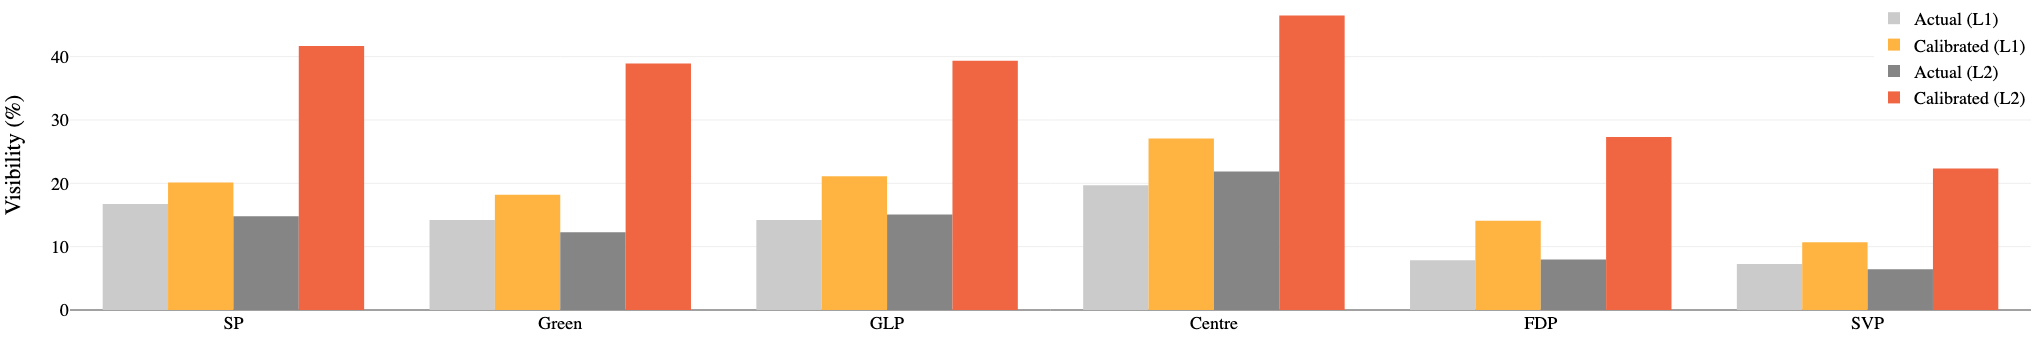

In [85]:
save_paper_figure(fig, 'what_if_neutral_answering_strategy_recommendation_share_L2_L1_big_parties_2023_sv_tiebreaking_times_roman_5x3_both_actual_times_bottommargin_english', height=360, font_size=18, margin_b=50)

## Extreme Answers (CP-E)

In [269]:
# COMPUTE WHAT-IF ANALYSIS (ALL CANDIDATES OF A PARTY EMPLOY EXTREME ANSWERING STRATEGY)

#method_dfs = {}

for method in tqdm([m for m in EVAL_DISTANCE_METHODS[1:]]):
    ic(method)
    method_dfs[method] = {
        'candidates': {},
    }
    for party in tqdm(df_candidates['_party'].unique()):
        ic(party)
        df_candidates_modified = df_candidates.copy()
        df_voters_recommendations = df_voters.copy()
        candidate_party_mask = df_candidates_modified['_party'] == party
    
        # maximize answer strengths of all candidates in party
        df_candidates_modified.loc[candidate_party_mask, get_cols(df_candidates_modified)] = map_to_answer_possibilites(((df_candidates_modified[candidate_party_mask].a().to_numpy() - 50)*100)+50)
    
        # update answer strength stats
        df_candidates_modified.loc[candidate_party_mask, '_answer_strength'] = (df_candidates_modified[candidate_party_mask][get_cols(df_candidates_modified)] - 50).abs().mean(axis=1)
        df_candidates_modified.loc[candidate_party_mask, '_answer_strength_std'] = (df_candidates_modified[candidate_party_mask][get_cols(df_candidates_modified)] - 50).abs().std(axis=1)
    
        # calculate what if recommendations
        df_voters_recommendations = add_candidate_voting_recommendations(df_voters_recommendations, df_candidates_modified, distance_method=method)
    
        df_candidates_modified.add_recommendation_counts(df_voters_recommendations)
    
        ic(df_candidates_modified.columns[-5:])
    
        # store results
        method_dfs[method]['candidates'][party] = df_candidates_modified

    filename = 'data/cache/what_if_analysis_extreme_all_party_dfs_eval_methods_sv_tiebreaking_recommendations.pkl'
    with open(filename, 'wb') as file:
        # Serialize the dictionary and write it to the file
        pickle.dump(method_dfs, file)

  0%|                                                                                                                                                                                     | 0/6 [00:00<?, ?it/s]ic| method: 'L1'

  0%|                                                                                                                                                                                    | 0/13 [00:00<?, ?it/s]ic| party: 'Grüne'


  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/104826 [00:00<?, ?it/s]

  0%|          | 0/5023 [00:00<?, ?it/s]

  0%|          | 0/89378 [00:00<?, ?it/s]

...

  0%|          | 0/892 [00:00<?, ?it/s]

  0%|          | 0/353 [00:00<?, ?it/s]

  0%|          | 0/806 [00:00<?, ?it/s]

  0%|          | 0/662 [00:00<?, ?it/s]

ic| df_candidates_modified.columns[-5:]: Index(['_answer_strength_std', '_n_recommendations_spc_DM_HYBRID',
                                                '_n_recommendations_top_DM_HYBRID',
                                                '_n_recommendations_spc_DM_HYBRID_normalized',
                                                '_n_recommendations_top_DM_HYBRID_normalized'],
                                               dtype='object')

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [8:49:12<00:00, 5292.01s/it]


In [38]:
# LOAD

filename = 'data/cache/what_if_analysis_extreme_all_party_dfs_eval_methods_sv_tiebreaking_recommendations.pkl'
with open(filename, 'rb') as file:
    # Serialize the dictionary and write it to the file
    method_dfs = pickle.load(file)

In [63]:
# SAVE

import pickle

filename = 'data/cache/what_if_analysis_extreme_all_party_dfs_eval_methods_sv_tiebreaking_recommendations.pkl'
with open(filename, 'wb') as file:
    # Serialize the dictionary and write it to the file
    pickle.dump(method_dfs, file)

In [62]:
# ANALYZE

#party_col = 'party_short'
#unique_parties = df_candidates[party_col].unique()

#party_col, unique_parties = '_party', BIG_PARTIES

party_col, unique_parties = '_party', df_candidates['_party'].unique()

dfs_analysis = []
for method in method_dfs:
    manipulated_strengths = []
    for party in unique_parties:
        manipulated_strengths.append(method_dfs[method]['candidates'][party].get_party_visibilities(party_col=party_col).loc[party, f'Party Visibility ({method})'])

    df_party_strengths = df_candidates.get_party_visibilities(party_col=party_col)
    df_analysis = df_party_strengths[f'Party Visibility ({method})'].to_frame().join(pd.DataFrame(index=unique_parties, data=manipulated_strengths, columns=[f'Manipulated ({method})'])).rename(columns={f'Party Visibility ({method})': f'Actual ({method})'})
    dfs_analysis.append(df_analysis)

df_analysis = pd.concat(dfs_analysis, axis=1)

for method in np.unique([c.split('(')[1].split(')')[0] for c in df_analysis.columns if '(' in c]):
    df_analysis[f'Ratio ({method})'] = ((df_analysis[f'Manipulated ({method})'] / df_analysis[f'Actual ({method})']))
    df_analysis[f'Gain ({method})'] = ((df_analysis[f'Manipulated ({method})'] - df_analysis[f'Actual ({method})']))

df_analysis

,Actual (L2_sv),Manipulated (L2_sv),Actual (L1),Manipulated (L1),Actual (AC),Manipulated (AC),Actual (angular),Manipulated (angular),Actual (mahalanobis_unweighted),Manipulated (mahalanobis_unweighted),Actual (DM_L1_BONUS),Manipulated (DM_L1_BONUS),Actual (DM_HYBRID),Manipulated (DM_HYBRID),Ratio (AC),Gain (AC),Ratio (DM_HYBRID),Gain (DM_HYBRID),Ratio (DM_L1_BONUS),Gain (DM_L1_BONUS),Ratio (L1),Gain (L1),Ratio (L2_sv),Gain (L2_sv),Ratio (angular),Gain (angular),Ratio (mahalanobis_unweighted),Gain (mahalanobis_unweighted)
_party,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Andere,0.073464,0.014630,0.068634,0.032029,0.076723,0.083999,0.067122,0.058576,0.046752,0.011555,0.074424,0.102354,0.067417,0.063435,1.094829,0.007276,0.940937,-0.003982,1.375291,0.027931,0.466660,-0.036605,0.199141,-0.058834,0.872669,-0.008547,0.247161,-0.035197
Centre,0.218844,0.027374,0.196895,0.060704,0.160995,0.125853,0.158310,0.140984,0.147020,0.017399,0.130583,0.185846,0.158184,0.126984,0.781722,-0.035141,0.802761,-0.031200,1.423203,0.055263,0.308306,-0.136191,0.125086,-0.191470,0.890553,-0.017327,0.118344,-0.129621
EDU,0.028473,0.005542,0.027791,0.012458,0.027217,0.034479,0.026969,0.023034,0.014318,0.002444,0.025580,0.038194,0.026244,0.022190,1.266823,0.007262,0.845539,-0.004054,1.493116,0.012614,0.448288,-0.015332,0.194646,-0.022931,0.854098,-0.003935,0.170673,-0.011874
EVP,0.084871,0.009773,0.074691,0.023168,0.060690,0.063625,0.064592,0.055648,0.053968,0.006842,0.048707,0.088292,0.059966,0.053014,1.048363,0.002935,0.884068,-0.006952,1.812739,0.039586,0.310189,-0.051523,0.115155,-0.075098,0.861522,-0.008945,0.126784,-0.047125
FDP,0.079726,0.016831,0.078578,0.035521,0.077889,0.084655,0.081963,0.074421,0.053699,0.009183,0.080764,0.108702,0.080737,0.068916,1.086873,0.006766,0.853588,-0.011821,1.345919,0.027938,0.452053,-0.043056,0.211111,-0.062895,0.907979,-0.007542,0.171009,-0.044516
GLP,0.150703,0.021393,0.141973,0.045013,0.129672,0.097136,0.119243,0.105323,0.157521,0.024223,0.098981,0.146517,0.114439,0.102306,0.749088,-0.032536,0.893985,-0.012132,1.480257,0.047536,0.317057,-0.096959,0.141954,-0.129310,0.883267,-0.013920,0.153774,-0.133298
Green,0.122854,0.048696,0.142125,0.086269,0.165375,0.157030,0.172944,0.142429,0.232599,0.124750,0.200888,0.229446,0.182498,0.173337,0.949541,-0.008345,0.949806,-0.009160,1.142163,0.028559,0.606997,-0.055855,0.396370,-0.074159,0.823555,-0.030515,0.536331,-0.107849
Lega,0.000599,0.000122,0.000649,0.000332,0.000602,0.000894,0.000681,0.000552,0.000423,0.000093,0.000654,0.000992,0.000682,0.000577,1.485885,0.000292,0.845660,-0.000105,1.517119,0.000338,0.511102,-0.000317,0.204038,-0.000477,0.810964,-0.000129,0.220669,-0.000330
MCG,0.001414,0.000325,0.001645,0.000772,0.001888,0.001831,0.001889,0.001646,0.000540,0.000152,0.002124,0.002311,0.001880,0.001473,0.969480,-0.000058,0.783668,-0.000407,1.088280,0.000187,0.469183,-0.000873,0.229892,-0.001089,0.870994,-0.000244,0.281181,-0.000389


In [297]:
df_analysis.style.background_gradient(cmap='Blues_r', axis=0)

,Actual (L2_sv),Manipulated (L2_sv),Actual (L1),Manipulated (L1),Actual (AC),Manipulated (AC),Actual (angular),Manipulated (angular),Actual (mahalanobis_unweighted),Manipulated (mahalanobis_unweighted),Actual (DM_L1_BONUS),Manipulated (DM_L1_BONUS),Actual (DM_HYBRID),Manipulated (DM_HYBRID),Ratio (AC),Gain (AC),Ratio (DM_HYBRID),Gain (DM_HYBRID),Ratio (DM_L1_BONUS),Gain (DM_L1_BONUS),Ratio (L1),Gain (L1),Ratio (L2_sv),Gain (L2_sv),Ratio (angular),Gain (angular),Ratio (mahalanobis_unweighted),Gain (mahalanobis_unweighted)
_party,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Andere,0.073464,0.014630,0.068634,0.032029,0.076723,0.083999,0.067122,0.058576,0.046752,0.011555,0.074424,0.102354,0.067417,0.063435,1.094829,0.007276,0.940937,-0.003982,1.375291,0.027931,0.466660,-0.036605,0.199141,-0.058834,0.872669,-0.008547,0.247161,-0.035197
EDU,0.028473,0.005542,0.027791,0.012458,0.027217,0.034479,0.026969,0.023034,0.014318,0.002444,0.025580,0.038194,0.026244,0.022190,1.266823,0.007262,0.845539,-0.004054,1.493116,0.012614,0.448288,-0.015332,0.194646,-0.022931,0.854098,-0.003935,0.170673,-0.011874
EVP,0.084871,0.009773,0.074691,0.023168,0.060690,0.063625,0.064592,0.055648,0.053968,0.006842,0.048707,0.088292,0.059966,0.053014,1.048363,0.002935,0.884068,-0.006952,1.812739,0.039586,0.310189,-0.051523,0.115155,-0.075098,0.861522,-0.008945,0.126784,-0.047125
FDP,0.079726,0.016831,0.078578,0.035521,0.077889,0.084655,0.081963,0.074421,0.053699,0.009183,0.080764,0.108702,0.080737,0.068916,1.086873,0.006766,0.853588,-0.011821,1.345919,0.027938,0.452053,-0.043056,0.211111,-0.062895,0.907979,-0.007542,0.171009,-0.044516
GLP,0.150703,0.021393,0.141973,0.045013,0.129672,0.097136,0.119243,0.105323,0.157521,0.024223,0.098981,0.146517,0.114439,0.102306,0.749088,-0.032536,0.893985,-0.012132,1.480257,0.047536,0.317057,-0.096959,0.141954,-0.129310,0.883267,-0.013920,0.153774,-0.133298
Grüne,0.122854,0.048696,0.142125,0.086269,0.165375,0.157030,0.172944,0.142429,0.232599,0.124750,0.200888,0.229446,0.182498,0.173337,0.949541,-0.008345,0.949806,-0.009160,1.142163,0.028559,0.606997,-0.055855,0.396370,-0.074159,0.823555,-0.030515,0.536331,-0.107849
Lega,0.000599,0.000122,0.000649,0.000332,0.000602,0.000894,0.000681,0.000552,0.000423,0.000093,0.000654,0.000992,0.000682,0.000577,1.485885,0.000292,0.845660,-0.000105,1.517119,0.000338,0.511102,-0.000317,0.204038,-0.000477,0.810964,-0.000129,0.220669,-0.000330
MCG,0.001414,0.000325,0.001645,0.000772,0.001888,0.001831,0.001889,0.001646,0.000540,0.000152,0.002124,0.002311,0.001880,0.001473,0.969480,-0.000058,0.783668,-0.000407,1.088280,0.000187,0.469183,-0.000873,0.229892,-0.001089,0.870994,-0.000244,0.281181,-0.000389
Mitte,0.218844,0.027374,0.196895,0.060704,0.160995,0.125853,0.158310,0.140984,0.147020,0.017399,0.130583,0.185846,0.158184,0.126984,0.781722,-0.035141,0.802761,-0.031200,1.423203,0.055263,0.308306,-0.136191,0.125086,-0.191470,0.890553,-0.017327,0.118344,-0.129621


In [65]:
df_candidates = df_candidates.add_n_votes()

/path/to/rsfp/rsfp/data.py:1169: UserWarning:

Votes have already been added to the DataFrame. Skipping.



In [66]:
df_analysis['Vote Share'] = df_analysis.index.map(df_candidates.get_party_visibilities()['Party Visibility (Actual Votes)'].to_dict())
df_analysis_parties = df_analysis.drop(index=['Andere', 'Parteilos'])
df_analysis_parties

,Actual (L2_sv),Manipulated (L2_sv),Actual (L1),Manipulated (L1),Actual (AC),Manipulated (AC),Actual (angular),Manipulated (angular),Actual (mahalanobis_unweighted),Manipulated (mahalanobis_unweighted),Actual (DM_L1_BONUS),Manipulated (DM_L1_BONUS),Actual (DM_HYBRID),Manipulated (DM_HYBRID),Ratio (AC),Gain (AC),Ratio (DM_HYBRID),Gain (DM_HYBRID),Ratio (DM_L1_BONUS),Gain (DM_L1_BONUS),Ratio (L1),Gain (L1),Ratio (L2_sv),Gain (L2_sv),Ratio (angular),Gain (angular),Ratio (mahalanobis_unweighted),Gain (mahalanobis_unweighted),Vote Share
_party,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Centre,0.218844,0.027374,0.196895,0.060704,0.160995,0.125853,0.158310,0.140984,0.147020,0.017399,0.130583,0.185846,0.158184,0.126984,0.781722,-0.035141,0.802761,-0.031200,1.423203,0.055263,0.308306,-0.136191,0.125086,-0.191470,0.890553,-0.017327,0.118344,-0.129621,0.146591
EDU,0.028473,0.005542,0.027791,0.012458,0.027217,0.034479,0.026969,0.023034,0.014318,0.002444,0.025580,0.038194,0.026244,0.022190,1.266823,0.007262,0.845539,-0.004054,1.493116,0.012614,0.448288,-0.015332,0.194646,-0.022931,0.854098,-0.003935,0.170673,-0.011874,0.011307
EVP,0.084871,0.009773,0.074691,0.023168,0.060690,0.063625,0.064592,0.055648,0.053968,0.006842,0.048707,0.088292,0.059966,0.053014,1.048363,0.002935,0.884068,-0.006952,1.812739,0.039586,0.310189,-0.051523,0.115155,-0.075098,0.861522,-0.008945,0.126784,-0.047125,0.019940
FDP,0.079726,0.016831,0.078578,0.035521,0.077889,0.084655,0.081963,0.074421,0.053699,0.009183,0.080764,0.108702,0.080737,0.068916,1.086873,0.006766,0.853588,-0.011821,1.345919,0.027938,0.452053,-0.043056,0.211111,-0.062895,0.907979,-0.007542,0.171009,-0.044516,0.138143
GLP,0.150703,0.021393,0.141973,0.045013,0.129672,0.097136,0.119243,0.105323,0.157521,0.024223,0.098981,0.146517,0.114439,0.102306,0.749088,-0.032536,0.893985,-0.012132,1.480257,0.047536,0.317057,-0.096959,0.141954,-0.129310,0.883267,-0.013920,0.153774,-0.133298,0.080449
Green,0.122854,0.048696,0.142125,0.086269,0.165375,0.157030,0.172944,0.142429,0.232599,0.124750,0.200888,0.229446,0.182498,0.173337,0.949541,-0.008345,0.949806,-0.009160,1.142163,0.028559,0.606997,-0.055855,0.396370,-0.074159,0.823555,-0.030515,0.536331,-0.107849,0.104057
Lega,0.000599,0.000122,0.000649,0.000332,0.000602,0.000894,0.000681,0.000552,0.000423,0.000093,0.000654,0.000992,0.000682,0.000577,1.485885,0.000292,0.845660,-0.000105,1.517119,0.000338,0.511102,-0.000317,0.204038,-0.000477,0.810964,-0.000129,0.220669,-0.000330,0.002239
MCG,0.001414,0.000325,0.001645,0.000772,0.001888,0.001831,0.001889,0.001646,0.000540,0.000152,0.002124,0.002311,0.001880,0.001473,0.969480,-0.000058,0.783668,-0.000407,1.088280,0.000187,0.469183,-0.000873,0.229892,-0.001089,0.870994,-0.000244,0.281181,-0.000389,0.003296
PdA,0.006876,0.002284,0.008320,0.004648,0.009522,0.012543,0.011951,0.009093,0.005848,0.002211,0.011749,0.015573,0.011159,0.009775,1.317321,0.003021,0.875985,-0.001384,1.325553,0.003825,0.558720,-0.003671,0.332206,-0.004592,0.760846,-0.002858,0.378164,-0.003636,0.004245


In [67]:
df_analysis[[c for c in df_analysis.columns if 'Gain' in c]].mean()

Gain (AC)                       -0.004645
Gain (DM_HYBRID)                -0.008406
Gain (DM_L1_BONUS)               0.022600
Gain (L1)                       -0.042792
Gain (L2_sv)                    -0.059534
Gain (angular)                  -0.010982
Gain (mahalanobis_unweighted)   -0.053016
dtype: float64

In [68]:
df_analysis.loc[BIG_PARTIES, 'Ratio (L2_sv)'] - 1

_party
SP       -0.662890
Green    -0.603630
GLP      -0.858046
Centre   -0.874914
FDP      -0.788889
SVP      -0.585513
Name: Ratio (L2_sv), dtype: float64

In [72]:
(df_analysis_parties[[c for c in df_analysis.columns if c.startswith('Ratio')]] * df_analysis_parties['Vote Share'].to_numpy().reshape(-1, 1)).sum() / df_analysis_parties['Vote Share'].sum() - 1


Ratio (AC)                       -0.038395
Ratio (DM_HYBRID)                -0.116557
Ratio (DM_L1_BONUS)               0.268395
Ratio (L1)                       -0.497591
Ratio (L2_sv)                    -0.707895
Ratio (angular)                  -0.129537
Ratio (mahalanobis_unweighted)   -0.694062
dtype: float64

### Metric (CP-E)

In [74]:
# CP-E

((df_analysis_parties[[c for c in df_analysis.columns if c.startswith('Ratio')]] * df_analysis_parties['Vote Share'].to_numpy().reshape(-1, 1)).sum() / df_analysis_parties['Vote Share'].sum() - 1).to_frame().loc[[f'Ratio ({method})' for method in EVAL_DISTANCE_METHODS]]

,0
Ratio (L2_sv),-0.707895
Ratio (L1),-0.497591
Ratio (AC),-0.038395
Ratio (angular),-0.129537
Ratio (mahalanobis_unweighted),-0.694062
Ratio (DM_L1_BONUS),0.268395
Ratio (DM_HYBRID),-0.116557


# Question Favoritism (QF)

In [174]:
# COMPUTE (only deluxe voters)

df_greedy_forward_selection = pd.DataFrame()

district = 'SG'
df_v = df_voters[(df_voters['_district']==district) & (df_voters['questTYPE']==1)]
df_c = df_candidates.district(district)

for party in tqdm([p for p in df_c['_party'].unique() if p not in [c.split()[0] for c in df_greedy_forward_selection.columns] and p not in ['Andere', 'Parteilos']]):
    ic(party)
    selected_cols = []
    party_strengths = []

    for _ in tqdm(range(75)):
        best_curr_cols_party_strength = 0
        available_cols = [c for c in range(75) if c not in selected_cols]
    
        for col in tqdm(available_cols):
            curr_cols = list(selected_cols + [col])
            curr_cols_bool_index = np.zeros(75)
            curr_cols_bool_index[curr_cols] = 1
            curr_cols_bool_index = curr_cols_bool_index.astype(bool)
    
            df_v_curr_cols = SVDataFrame(df_v, answer_cols=np.array(get_cols(df_v))[curr_cols_bool_index], weight_cols=np.array(get_cols(df_v, col_type='weight'))[curr_cols_bool_index])
            df_c_curr_cols = SVDataFrame(df_c, answer_cols=np.array(get_cols(df_c))[curr_cols_bool_index])

            df_v_curr_cols = add_candidate_voting_recommendations(df_v_curr_cols, df_c_curr_cols, progress_bar=False)
            df_c_curr_cols = df_c_curr_cols.add_recommendation_counts(df_v_curr_cols)
    
            curr_cols_party_strength = df_c_curr_cols.get_party_visibilities().loc[party].item()
            #ic(curr_cols_party_strength)
    
            if curr_cols_party_strength > best_curr_cols_party_strength:
                best_curr_cols_party_strength = curr_cols_party_strength
                next_selected_cols = curr_cols.copy()
        
        selected_cols = next_selected_cols.copy()
        party_strengths.append(best_curr_cols_party_strength)
        ic(best_curr_cols_party_strength)
        #ic(selected_cols)
    
    df_greedy_forward_selection[f"{party} selection"] = selected_cols
    df_greedy_forward_selection[f"{party} strength"] = party_strengths

    # SAVE
    #df_greedy_forward_selection.to_csv(f'df_greedy_forward_selection_{district}_deluxe.csv')

  0%|          | 0/4 [00:00<?, ?it/s]

ic| party: 'GLP'


  0%|          | 0/75 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]

ic| best_curr_cols_party_strength: 0.18189549030655897


...

ic| best_curr_cols_party_strength: 0.1057409378325925


  0%|          | 0/2 [00:00<?, ?it/s]

ic| best_curr_cols_party_strength: 0.09243723783885306


  0%|          | 0/1 [00:00<?, ?it/s]

ic| best_curr_cols_party_strength: 0.08057868486404139


In [75]:
# Load Greedy Forward Selection Data

#df_greedy_forward_selection = pd.read_csv('df_greedy_forward_selection_SG_all.csv', index_col=0)
df_greedy_forward_selection = pd.read_csv('df_greedy_forward_selection_SG_deluxe.csv', index_col=0)

In [79]:
for c in [c for c in df_greedy_forward_selection.columns if c.endswith('strength')]:
    df_greedy_forward_selection[f"{c.split()[0]}"] = 100 * (df_greedy_forward_selection[c] / df_greedy_forward_selection[c].min() - 1)
    df_greedy_forward_selection[f"{c.split()[0]} diff"] = df_greedy_forward_selection[c] - df_greedy_forward_selection[c].min()

df_greedy_forward_selection['# Questions'] = df_greedy_forward_selection.index+1

df_greedy_forward_selection[[c.split()[0] for c in df_greedy_forward_selection.columns if c.endswith('strength')]+['# Questions']].melt(id_vars='# Questions', var_name='Party', value_name='Party Visibility')

,# Questions,Party,Party Visibility
0,1,Centre,23.503384
1,2,Centre,23.081356
2,3,Centre,28.863315
3,4,Centre,37.471183
4,5,Centre,45.809474
...,...,...,...
595,71,EVP,57.908708
596,72,EVP,48.682421
597,73,EVP,31.226934
598,74,EVP,14.716737


In [81]:
df_melted = df_greedy_forward_selection[[c.split()[0] for c in df_greedy_forward_selection.columns if c.endswith('strength')]+['# Questions']].melt(id_vars='# Questions', var_name='Party', value_name='Party Visibility')

df_melted

,# Questions,Party,Party Visibility
0,1,Centre,23.503384
1,2,Centre,23.081356
2,3,Centre,28.863315
3,4,Centre,37.471183
4,5,Centre,45.809474
...,...,...,...
595,71,EVP,57.908708
596,72,EVP,48.682421
597,73,EVP,31.226934
598,74,EVP,14.716737


### Plot

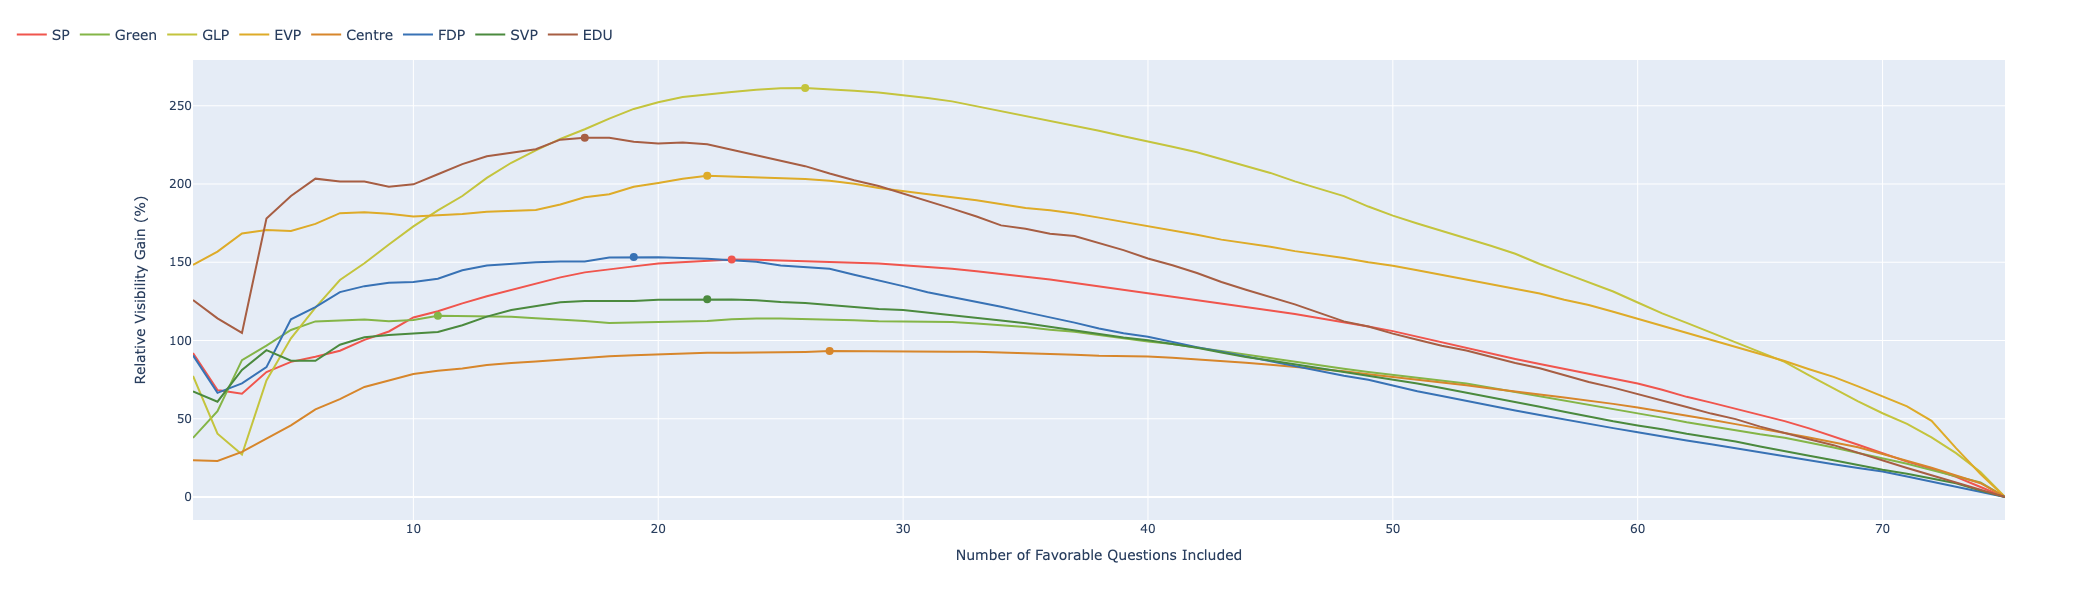

In [82]:
# VISUALIZE

fig = px.line(
    df_melted,
    x='# Questions',
    y='Party Visibility', 
    color='Party',
    width=1200, 
    height=800,
    color_discrete_map=PARTY2COLOR,
    category_orders={'Party': PARTIES_LEFT_TO_RIGHT},
)



# Find the maximum y-value for each group in 'variable' and add a cross marker
for variable in df_melted['Party'].unique():
    max_row = df_melted[df_melted['Party'] == variable].loc[df_melted[df_melted['Party'] == variable]['Party Visibility'].idxmax()]
    fig.add_trace(go.Scatter(
        x=[max_row['# Questions']],
        y=[max_row['Party Visibility']],
        mode='markers',
        marker=dict(symbol='circle', size=8, color=PARTY2COLOR[variable]),
        name=f'{variable}',
        showlegend=False,
    ))


#for party in [p for p in PARTIES_LEFT_TO_RIGHT if p in df_melted['Party'].unique()]:
#    fig.add_trace(go.Scatter(
#        x=[None],
#        y=[None],
#        mode='lines+markers',
#        line=dict(color=PARTY2COLOR[party], width=2),
#        marker=dict(symbol='circle', size=8, color=PARTY2COLOR[party]),
#        showlegend=True,
#        name=party,
#    ))


# Update layout for secondary y-axis
fig.update_layout(
    xaxis_title='Number of Favorable Questions Included',
    yaxis_title='Relative Visibility Gain (%)',
    legend_title='Party',
    width=1000,
    height=600,
    legend=dict(
        title=None,
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=-0.1,
        font=dict(size=14),
        #itemwidth=60,
    )
)

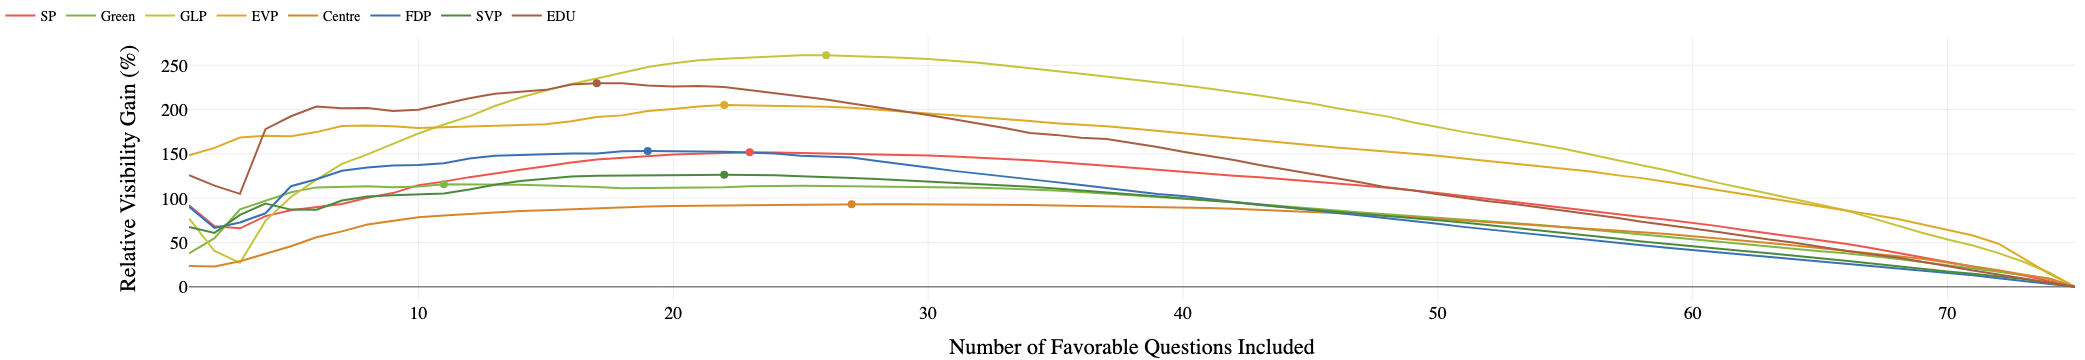

In [36]:
# SAVE VISUALIZATION

save_paper_figure(fig, 'question_favoritism_SG_deluxe_relative_difference_5x3_maxmarkers_circles_custom_legend_times_english', height=360, font_size=18)

## Question Order

In [215]:
# CALCULATE EMPIRICAL DROP RATES

import statsmodels.api as sm
df_response_frequencies = (~df_voters[(df_voters['questTYPE']==1)].a().isna()).mean().to_frame().rename(columns={0:'all voters'}).reset_index()

x = df_response_frequencies.index
y = df_response_frequencies['all voters']

# Add a constant to the independent variables for intercept calculation
x_with_const = sm.add_constant(x)

model = sm.OLS(y, x_with_const).fit()
slope, intercept = model.params[1], model.params[0]

ic(slope, intercept)

empirical_ols_drop_rates = [1-(intercept + i * slope) for i in range(75)]
empirical_ols_drop_rates

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_17132/4012616453.py:13: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

ic| slope: -0.0012398103688485668, intercept: 0.960747091497143


[0.03925290850285701,
 0.04049271887170558,
 0.04173252924055415,
 0.04297233960940272,
 0.04421214997825129,
 0.04545196034709986,
 0.04669177071594843,
 0.047931581084797004,
 0.049171391453645574,
 0.050411201822494145,
 0.051651012191342716,
 0.052890822560191286,
 0.05413063292903986,
 0.05537044329788843,
 0.056610253666737,
 0.05785006403558546,
 0.05908987440443403,
 0.0603296847732826,
 0.06156949514213117,
 0.06280930551097974,
 0.06404911587982831,
 0.06528892624867688,
 0.06652873661752545,
 0.06776854698637402,
 0.0690083573552226,
 0.07024816772407116,
 0.07148797809291974,
 0.0727277884617683,
 0.07396759883061688,
 0.07520740919946545,
 0.07644721956831402,
 0.07768702993716259,
 0.07892684030601116,
 0.08016665067485973,
 0.0814064610437083,
 0.08264627141255687,
 0.08388608178140544,
 0.08512589215025401,
 0.08636570251910258,
 0.08760551288795115,
 0.08884532325679972,
 0.0900851336256483,
 0.09132494399449675,
 0.09256475436334544,
 0.0938045647321939,
 0.0950443751

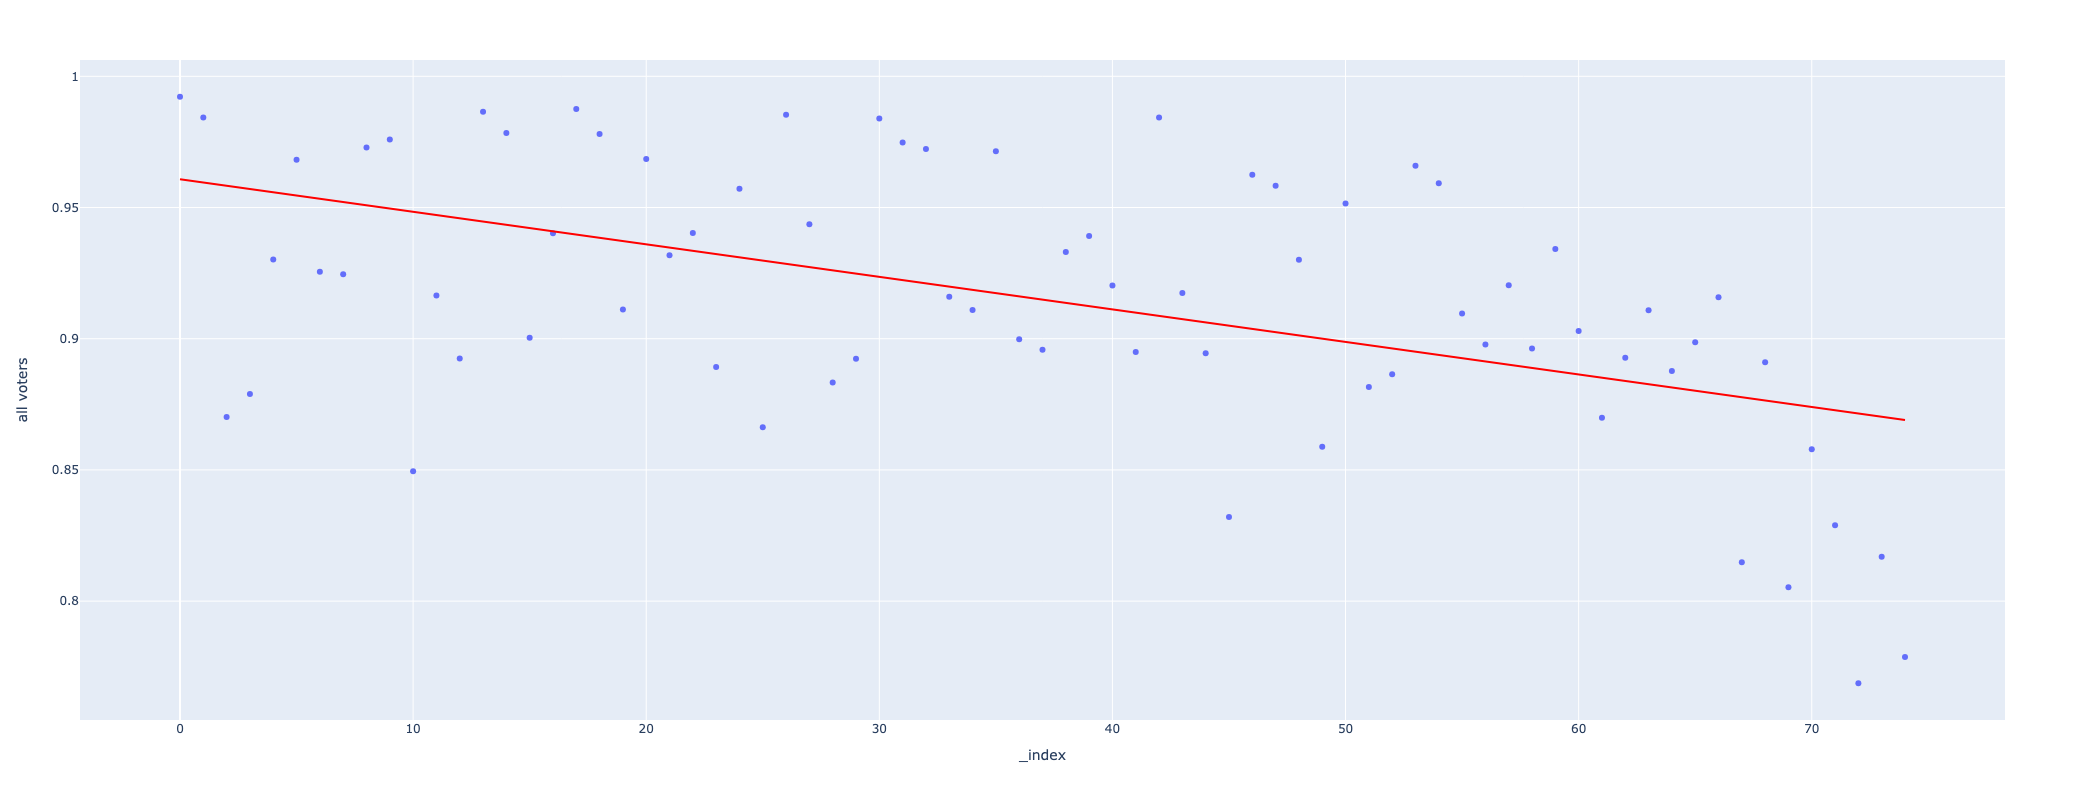

In [249]:
# VISUALIZE DROP RATES

px.scatter((~df_voters[(df_voters['questTYPE']==1)].a().isna()).mean().to_frame().rename(columns={0:'all voters'}).reset_index(), y='all voters', trendline='ols', trendline_color_override='red', height=800, width=1200)

In [216]:
def drop_values_randomly(df, drop_rates_dict, seed=None):
    # Set the seed for reproducibility
    if seed is not None:
        np.random.seed(seed)
    
    # Copy the DataFrame to avoid modifying the original
    df_copy = df.copy()
    
    for col, rate in drop_rates_dict.items():
        mask = np.random.rand(len(df_copy)) < rate
        df_copy.loc[mask, col] = np.nan
    return df_copy

In [217]:
# default Party Visibilitys based on voters that answered all questions
district = 'SG'
df_v_all = df_voters[(df_voters['_district']==district) & (df_voters['N_answers']==75)]
df_c = df_candidates.district(district)

df_v_all = add_candidate_voting_recommendations(df_v_all, df_c)
df_c = df_c.add_recommendation_counts(df_v_all)

df_party_strengths_all_answers = df_c.get_party_visibilities()
df_party_strengths_all_answers

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/5504 [00:00<?, ?it/s]

,Party Strength (L2_sv)
_party,
Andere,0.016700
EDU,0.030326
EVP,0.081138
FDP,0.168393
GLP,0.108603
Grüne,0.132055
Mitte,0.279418
SP,0.126075
SVP,0.057292


In [218]:
N_repeats = 10

parties_in_df = [c.split()[0] for c in df_greedy_forward_selection.columns if c.endswith('selection')]
df_question_order_party_strengths = defaultdict(list)

for party in tqdm(parties_in_df):
    ic(party)
    
    for seed in tqdm(range(N_repeats)):
    
        drop_rates_dict = dict(zip(df_voters.a().columns[df_greedy_forward_selection[f'{party} selection'].to_numpy()], empirical_ols_drop_rates))
        df_v_all_dropped = drop_values_randomly(df_v_all, drop_rates_dict, seed=seed)
    
        df_v_all_dropped = add_candidate_voting_recommendations(df_v_all_dropped, df_c)
        df_c = df_c.add_recommendation_counts(df_v_all_dropped)

        modified_party_strength = df_c.get_party_visibilities().loc[party].item()
        df_question_order_party_strengths[party].append(modified_party_strength)

        ic(modified_party_strength)

df_question_order_party_strengths = pd.DataFrame(df_question_order_party_strengths)  
df_question_order_party_strengths

  0%|          | 0/8 [00:00<?, ?it/s]

ic| party: 'Mitte'


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/5504 [00:00<?, ?it/s]

...

ic| modified_party_strength: 0.08599806201550388


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/5504 [00:00<?, ?it/s]

ic| modified_party_strength: 0.08678536821705427


,Mitte,Grüne,FDP,SP,GLP,SVP,EDU,EVP
0,0.289729,0.136552,0.170815,0.130405,0.113190,0.057685,0.030826,0.086619
1,0.287791,0.137264,0.171345,0.129270,0.110541,0.057579,0.030493,0.086543
2,0.287064,0.135644,0.171406,0.130435,0.113327,0.056853,0.030766,0.086149
3,0.289577,0.138475,0.172254,0.131298,0.113539,0.056716,0.031038,0.085695
4,0.287170,0.137173,0.171360,0.129724,0.114462,0.057171,0.030750,0.086271
5,0.288154,0.136658,0.171633,0.130042,0.114614,0.057292,0.031174,0.085544
6,0.289426,0.137567,0.171300,0.130632,0.114780,0.057110,0.030796,0.085150
7,0.288911,0.136446,0.171421,0.129663,0.114901,0.057246,0.030841,0.087361
8,0.287427,0.136810,0.171345,0.129906,0.114053,0.057352,0.030705,0.085998
9,0.287821,0.137082,0.171360,0.129618,0.112978,0.056868,0.031477,0.086785


In [225]:
# RESULTS (RANDOM SAMPLES)
df_question_order_party_strengths

,Mitte,Grüne,FDP,SP,GLP,SVP,EDU,EVP
0,0.289729,0.136552,0.170815,0.130405,0.113190,0.057685,0.030826,0.086619
1,0.287791,0.137264,0.171345,0.129270,0.110541,0.057579,0.030493,0.086543
2,0.287064,0.135644,0.171406,0.130435,0.113327,0.056853,0.030766,0.086149
3,0.289577,0.138475,0.172254,0.131298,0.113539,0.056716,0.031038,0.085695
4,0.287170,0.137173,0.171360,0.129724,0.114462,0.057171,0.030750,0.086271
5,0.288154,0.136658,0.171633,0.130042,0.114614,0.057292,0.031174,0.085544
6,0.289426,0.137567,0.171300,0.130632,0.114780,0.057110,0.030796,0.085150
7,0.288911,0.136446,0.171421,0.129663,0.114901,0.057246,0.030841,0.087361
8,0.287427,0.136810,0.171345,0.129906,0.114053,0.057352,0.030705,0.085998
9,0.287821,0.137082,0.171360,0.129618,0.112978,0.056868,0.031477,0.086785


In [226]:
# BEFORE Party VisibilityS
df_party_strengths_all_answers.iloc[:, 0]

_party
Andere    0.016700
EDU       0.030326
EVP       0.081138
FDP       0.168393
GLP       0.108603
Grüne     0.132055
Mitte     0.279418
SP        0.126075
SVP       0.057292
Name: Party Strength (L2_sv), dtype: float64

In [231]:
# AVERAGE DIFFERENCE
(df_question_order_party_strengths - df_party_strengths_all_answers.iloc[:, 0]).mean()

Andere         NaN
EDU       0.000560
EVP       0.005074
FDP       0.003031
GLP       0.005036
Grüne     0.004912
Mitte     0.008889
SP        0.004024
SVP      -0.000104
dtype: float64

In [228]:
# STANDARD DEVIATION OF DIFFERENCE
(df_question_order_party_strengths - df_party_strengths_all_answers.iloc[:, 0]).std()

Andere         NaN
EDU       0.000277
EVP       0.000651
FDP       0.000356
GLP       0.001293
Grüne     0.000752
Mitte     0.001021
SP        0.000598
SVP       0.000314
dtype: float64

In [236]:
# AVERAGE RATIO
(df_question_order_party_strengths / df_party_strengths_all_answers.iloc[:, 0]).mean() - 1

Andere         NaN
EDU       0.018472
EVP       0.062530
FDP       0.018000
GLP       0.046368
Grüne     0.037193
Mitte     0.031813
SP        0.031920
SVP      -0.001823
dtype: float64

In [233]:
# STANDARD DEVIATION OF RATIO
(df_question_order_party_strengths / df_party_strengths_all_answers.iloc[:, 0]).std()

Andere         NaN
EDU       0.009127
EVP       0.008027
FDP       0.002112
GLP       0.011903
Grüne     0.005696
Mitte     0.003656
SP        0.004745
SVP       0.005475
dtype: float64

# Question Type Importance

In [53]:
df_voters['_party'].unique()

array([None, 'Keine', 'SVP', 'SP', 'Grüne', 'GLP', 'FDP', 'AL', 'Mitte',
       'Andere', 'PdA', 'MCG', 'EVP', 'EDU', 'Lega'], dtype=object)

In [57]:
X = df_voters[df_voters['_party'].isin([v for v in df_voters['_party'].unique() if v != 'Keine' and v is not None])].a().to_numpy()

In [59]:
y = df_voters[df_voters['_party'].isin([v for v in df_voters['_party'].unique() if v != 'Keine' and v is not None])]['_party'].to_numpy()

In [91]:
X = df_voters[(df_voters['_party'].isin([v for v in df_voters['_party'].unique() if v != 'Keine' and v is not None])) & (df_voters['questTYPE'] == 1)].a().to_numpy()
y = df_voters[(df_voters['_party'].isin([v for v in df_voters['_party'].unique() if v != 'Keine' and v is not None])) & (df_voters['questTYPE'] == 1)]['_party'].to_numpy()

In [95]:
X = df_voters[(df_voters['_party'].isin([v for v in df_voters['_party'].unique() if v != 'Keine' and v is not None])) & (df_voters['N_answers'] == 75)].a().to_numpy()
y = df_voters[(df_voters['_party'].isin([v for v in df_voters['_party'].unique() if v != 'Keine' and v is not None])) & (df_voters['N_answers'] == 75)]['_party'].to_numpy()

In [96]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import pandas as pd

rfc = RandomForestClassifier()
rfc.fit(X, y)

RandomForestClassifier()

In [75]:
from sklearn.ensemble import HistGradientBoostingClassifier
hgbc = HistGradientBoostingClassifier()
hgbc.fit(X, y)

HistGradientBoostingClassifier()

In [97]:
df_questions['RFC_feature_importance'] = rfc.feature_importances_
#df_questions['HGBC_feature_importance'] = hgbc.feature_importances_

In [85]:
df_questions[df_questions['rapide']==1]

,ID_election,ID_question,question_DE,question_FR,question_IT,question_EN,category,tag_1,tag_2,tag_3,tag_4,tag_5,type,rapide,cleavage_1,cleavage_2,cleavage_3,cleavage_4,cleavage_5,cleavage_6,cleavage_7,cleavage_8,info_DE,pro_DE,contra_DE,_category,_n_options,RFC_feature_importance
0,1057,32214,Befürworten Sie eine Erhöhung des Rentenalters (z.B. auf 67 Jahre)?,Êtes-vous favorable à une augmentation de l'âge de la retraite (p. ex. à 67 ans) ?,È favorevole all’innalzamento dell’età pensionabile (ad es. a 67 anni)?,"Do you support an increase in the retirement age (e.g., to 67)?",11451,2,1,168.0,NaN,NaN,4-options,1,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,<p>Die Alters- und Hinterlassenenversicherung (AHV) geh&ouml;rt zu den wichtigsten Sozialwerken der Schweiz und ist ein wesentlicher Pfeiler der schweizerischen Altersvorsorge. Sie ist eine obliga...,"<p dir=""ltr"">Das Rentensystem muss aufgrund der gestiegenen Lebenserwartung und des Geburtenr&uuml;ckgangs angepasst werden. Ohne eine Erh&ouml;hung des Rentenalters werden immer weniger Erwerbst&...","<p dir=""ltr"">Die Erh&ouml;hung des Rentenalters widerspricht den Realit&auml;ten des Arbeitsmarktes. Bereits heute werden immer mehr Personen fr&uuml;hzeitig pensioniert &ndash; ungef&auml;hr ein ...",Welfare state & family,4,0.024707
1,1057,32215,Soll der Staat mehr Mittel für die Krankenkassen-Prämienverbilligung zur Verfügung stellen?,L'État doit-il allouer davantage de moyens à la réduction des primes d'assurance maladie ?,Ritiene che lo Stato dovrebbe stanziare più mezzi per la riduzione dei premi dell'assicurazione malattia?,Should the federal government allocate more funding for health insurance premium subsidies?,11451,168,122,7.0,NaN,NaN,4-options,1,NaN,NaN,-1.0,NaN,NaN,NaN,1.0,NaN,"<p dir=""ltr"">Die Krankenkassenpr&auml;mie ist der Beitrag, den eine Privatperson jeden Monat f&uuml;r die Versicherung bezahlen muss. Die H&ouml;he der Kosten h&auml;ngt von der Versicherung und F...","<p dir=""ltr"">Die Kosten der Krankenkassenpr&auml;mien steigen stetig und belasten viele Personen mit geringem Einkommen. Der Bund k&ouml;nnte dem entgegenwirken.</p>\n<p dir=""ltr"">Die Kaufkraft de...","<p dir=""ltr"">Die Kantone sind zust&auml;ndig f&uuml;r die Spitalplanung. Es ist nicht gerechtfertigt, wenn der Bund die steigenden Kosten des Gesundheitswesens kompensieren muss.</p>\n<p dir=""ltr""...",Welfare state & family,4,0.021470
5,1057,32219,Soll der Bund den gemeinnützigen Wohnungsbau finanziell stärker fördern? [BePart-Frage],La Confédération doit-elle renforcer son soutien financier à la construction de logements d'utilité publique ? [Question de BePart],Ritiene che la Confederazione dovrebbe fornire un maggiore sostegno finanziario all’edilizia abitativa di pubblica utilità? [Domanda BePart],Should the federal government provide more financial support for public housing construction? [BePart question],11451,168,46,NaN,NaN,NaN,4-options,1,NaN,NaN,-1.0,NaN,NaN,NaN,1.0,NaN,"<p dir=""ltr"">Gemeinn&uuml;tzige Bautr&auml;ger orientieren sich an der Kostenmiete und wirtschaften ohne Gewinnabsichten. Damit spielen sie insbesondere f&uuml;r die Wohnungsversorgung von Bev&oum...","<p dir=""ltr"">Aufgrund steigender Mietpreise in St&auml;dten und Agglomerationen finden Familien, &auml;ltere und junge Menschen keine bezahlbaren Wohnungen mehr. Der Bund nutzt die Massnahmen zur ...","<p dir=""ltr"">Aufgabe der Wohnbaupolitik ist auf der Stufe der Kantone und Gemeinden besser angesiedelt, da sie sich mit den Verh&auml;ltnissen vor Ort besser auskennen.</p>\n<p dir=""ltr"">Der Bund ...",Welfare state & family,4,0.027030
8,1057,32222,Sollen sich die Versicherten stärker an den Gesundheitskosten beteiligen (z.B. Erhöhung der Mindestfranchise)?,Les personnes assurées doivent-elles participer davantage aux frais de santé (p. ex. augmentation de la franchise minimale) ?,Ritiene che gli assicurati dovrebbero contribuire maggiormente ai costi sanitari (ad es. aumento della franchigia minima)?,"Should insure

In [78]:
# all
df_questions.groupby('type')['RFC_feature_importance'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
4-options,60.0,0.014103,0.007298,0.005022,0.007584,0.011781,0.019960,0.031960
5-options,8.0,0.008679,0.001734,0.006039,0.007896,0.008591,0.009718,0.011268
7-options,7.0,0.012057,0.002056,0.010413,0.010862,0.011227,0.012350,0.016333


In [94]:
# questTYPE==1
df_questions.groupby('type')['RFC_feature_importance'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
4-options,60.0,0.012544,0.003325,0.007147,0.010653,0.011458,0.013391,0.025066
5-options,8.0,0.013935,0.004772,0.008764,0.011776,0.012895,0.015046,0.024388
7-options,7.0,0.019408,0.004691,0.014875,0.015853,0.016623,0.023038,0.026573


In [94]:
# questTYPE==1
df_questions.groupby('type')['RFC_feature_importance'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
4-options,60.0,0.012544,0.003325,0.007147,0.010653,0.011458,0.013391,0.025066
5-options,8.0,0.013935,0.004772,0.008764,0.011776,0.012895,0.015046,0.024388
7-options,7.0,0.019408,0.004691,0.014875,0.015853,0.016623,0.023038,0.026573


In [ ]:
df_questions.groupby('type')[[c for c in df_questions.columns if c.endswith('feature_importance')]].describe()

In [63]:
model.feature_importances_

array([0.02518745, 0.02248003, 0.00765186, 0.00843725, 0.00724143,
       0.02813158, 0.00784147, 0.00764358, 0.01809496, 0.01719519,
       0.00789768, 0.007382  , 0.00787632, 0.0157218 , 0.02886133,
       0.00745049, 0.01956252, 0.02072765, 0.01807746, 0.00780624,
       0.02881184, 0.0064084 , 0.01947011, 0.00665058, 0.02083155,
       0.00772543, 0.02222591, 0.0175747 , 0.00799141, 0.00787599,
       0.02069139, 0.02281659, 0.02572034, 0.00754077, 0.00755439,
       0.02398169, 0.00619196, 0.00741807, 0.01938397, 0.02003259,
       0.00621489, 0.00681729, 0.01439221, 0.00505192, 0.00878954,
       0.00713278, 0.01451079, 0.01866461, 0.00668743, 0.00806508,
       0.01820721, 0.00800961, 0.00795563, 0.01763305, 0.02361711,
       0.00916354, 0.02077539, 0.00597293, 0.01829794, 0.02230732,
       0.01030343, 0.01630493, 0.01213582, 0.01082409, 0.01136614,
       0.01052174, 0.01301669, 0.01112496, 0.00608455, 0.01025654,
       0.00683094, 0.00938633, 0.0083539 , 0.00875988, 0.00829

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Assuming X_train and y_train are your features and target variable
model = RandomForestClassifier()
model.fit(X, y)

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

In [6]:
df_questions

,ID_election,ID_question,question_DE,question_FR,question_IT,question_EN,category,tag_1,tag_2,tag_3,tag_4,tag_5,type,rapide,cleavage_1,cleavage_2,cleavage_3,cleavage_4,cleavage_5,cleavage_6,cleavage_7,cleavage_8,info_DE,pro_DE,contra_DE,_category,_n_options
0,1057,32214,Befürworten Sie eine Erhöhung des Rentenalters (z.B. auf 67 Jahre)?,Êtes-vous favorable à une augmentation de l'âge de la retraite (p. ex. à 67 ans) ?,È favorevole all’innalzamento dell’età pensionabile (ad es. a 67 anni)?,"Do you support an increase in the retirement age (e.g., to 67)?",11451,2,1,168.0,NaN,NaN,4-options,1,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,NaN,<p>Die Alters- und Hinterlassenenversicherung (AHV) geh&ouml;rt zu den wichtigsten Sozialwerken der Schweiz und ist ein wesentlicher Pfeiler der schweizerischen Altersvorsorge. Sie ist eine obliga...,"<p dir=""ltr"">Das Rentensystem muss aufgrund der gestiegenen Lebenserwartung und des Geburtenr&uuml;ckgangs angepasst werden. Ohne eine Erh&ouml;hung des Rentenalters werden immer weniger Erwerbst&...","<p dir=""ltr"">Die Erh&ouml;hung des Rentenalters widerspricht den Realit&auml;ten des Arbeitsmarktes. Bereits heute werden immer mehr Personen fr&uuml;hzeitig pensioniert &ndash; ungef&auml;hr ein ...",Welfare state & family,4
1,1057,32215,Soll der Staat mehr Mittel für die Krankenkassen-Prämienverbilligung zur Verfügung stellen?,L'État doit-il allouer davantage de moyens à la réduction des primes d'assurance maladie ?,Ritiene che lo Stato dovrebbe stanziare più mezzi per la riduzione dei premi dell'assicurazione malattia?,Should the federal government allocate more funding for health insurance premium subsidies?,11451,168,122,7.0,NaN,NaN,4-options,1,NaN,NaN,-1.0,NaN,NaN,NaN,1.0,NaN,"<p dir=""ltr"">Die Krankenkassenpr&auml;mie ist der Beitrag, den eine Privatperson jeden Monat f&uuml;r die Versicherung bezahlen muss. Die H&ouml;he der Kosten h&auml;ngt von der Versicherung und F...","<p dir=""ltr"">Die Kosten der Krankenkassenpr&auml;mien steigen stetig und belasten viele Personen mit geringem Einkommen. Der Bund k&ouml;nnte dem entgegenwirken.</p>\n<p dir=""ltr"">Die Kaufkraft de...","<p dir=""ltr"">Die Kantone sind zust&auml;ndig f&uuml;r die Spitalplanung. Es ist nicht gerechtfertigt, wenn der Bund die steigenden Kosten des Gesundheitswesens kompensieren muss.</p>\n<p dir=""ltr""...",Welfare state & family,4
2,1057,32216,Bei Ehepaaren ist die Höhe der Rente heute auf 150% der maximalen individuellen AHV-Rente begrenzt (Plafonierung). Soll diese Begrenzung abgeschafft werden?,"Pour les couples mariés, le montant de la rente est aujourd'hui plafonné à 150% de la rente AVS individuelle maximale. Ce plafond doit-il être supprimé ?","Per le coppie di coniugi, l’ammontare della rendita è oggi limitato al 150% della rendita AVS individuale massima (tetto massimo). È favorevole all’abolizione di questa limitazione?","For married couples, the pension is currently limited to 150% of the maximum individual AHV pension (capping). Should this limit be eliminated?",11451,168,169,171.0,NaN,NaN,4-options,0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,"<p dir=""ltr"">Die AHV ist die Erste S&auml;ule der Altersvorsorge. Die 1. S&auml;ule soll den Rentner/-innen ein Einkommen garantieren, das die Grundbed&uuml;rfnisse in der Zeit nach der Pensionier...","<p dir=""ltr"">Die Plafonierung der AHV benachteiligt Ehepaare im Vergleich zu Einzelpersonen. Dies ist ungerecht, da der Zivilstand nicht die H&ouml;he des Wohlstands bestimmen sollte.</p>\n<p dir=...","<p dir=""ltr"">Die Aufhebung der Plafonierung belastet die AHV finanziell und gef&auml;hrdet deren langfristige Stabilit&auml;t.</p>\n<p dir=""ltr"">Bei der Plafonierung handelt es sich um eine unglei...",Welfare state & family,4
3,1057,32217,Im Rahmen der BVG-Reform sollen die Renten gekürzt werden (Senkung Mindestumwandlungssatz von 6.8% auf 6%). Befürworten Sie diese Massnahme?,"Dans le cadre de la réforme de la LPP, les rentes seraient réduites (baisse du taux de conversion minimal de 6

In [22]:
qt_boolean_index = np.full_like(question_type_boolean_index, False)
qt_boolean_index[np.random.choice(np.where(question_type_boolean_index)[0], 7)] = True
question_type_boolean_index = qt_boolean_index

In [26]:
question_type_boolean_index = df_questions['type'].isin(['4-options'])

# randomly sample from question_type
n_samples = 7
qt_boolean_index = np.full_like(question_type_boolean_index, False)
qt_boolean_index[np.random.choice(np.where(question_type_boolean_index)[0], n_samples)] = True
question_type_boolean_index = qt_boolean_index
ic(question_type_boolean_index)

df_voters_question_type = SVDataFrame(df_voters, answer_cols=np.array(get_cols(df_voters))[question_type_boolean_index], weight_cols=np.array(get_cols(df_voters, col_type='weight'))[question_type_boolean_index])
df_candidates_question_type = SVDataFrame(df_candidates, answer_cols=np.array(get_cols(df_candidates))[question_type_boolean_index])

ic| question_type_boolean_index: array([False, False, False, False, False,  True, False,  True, False,
                                        False, False, False, False, False, False, False, False, False,
                                        False, False, False, False, False,  True, False, False,  True,
                                        False, False, False, False,  True, False,  True, False, False,
                                        False, False, False, False, False, False, False, False, False,
                                        False, False, False, False, False, False, False, False,  True,
                                        False, False, False, False, False, False, False, False, False,
                                        False, False, False, False, False, False, False, False, False,
                                        False, False, False])


In [50]:
dfs_party_rank_metrics = []
question_type_boolean_index = df_questions['type'].isin(['4-options'])
n_samples = 7

for _ in tqdm(range(20)):

    # randomly sample from question_type
    qt_boolean_index = np.full_like(question_type_boolean_index, False)
    qt_boolean_index[np.random.choice(np.where(question_type_boolean_index)[0], n_samples)] = True
    question_type_boolean_index = qt_boolean_index
    ic(question_type_boolean_index)
    
    df_voters_question_type = SVDataFrame(df_voters, answer_cols=np.array(get_cols(df_voters))[question_type_boolean_index], weight_cols=np.array(get_cols(df_voters, col_type='weight'))[question_type_boolean_index])
    df_candidates_question_type = SVDataFrame(df_candidates, answer_cols=np.array(get_cols(df_candidates))[question_type_boolean_index])
    
    df_voters_question_type = add_list_voting_recommendations(
        df_voters_question_type, 
        df_candidates_question_type, 
        distance_method='L2_sv', 
        progress_bar=True
    )

    df_voters_question_type.map_lists_to_parties(df_candidates_question_type)
    df_voters_question_type.add_party_ranks(df_candidates_question_type, progress_bar=True)
    dfs_party_rank_metrics.append(df_voters_question_type.get_party_rank_metrics())

  0%|                                                                                                                                                                                    | 0/20 [00:00<?, ?it/s]ic| question_type_boolean_index: array([ True, False, False, False, False, False,  True, False, False,
                                        False, False, False, False,  True, False, False, False, False,
                                        False, False, False, False, False, False, False, False, False,
                                        False,  True, False, False, False, False, False, False,  True,
                                        False, False, False,  True, False, False, False, False, False,
                                        False, False, False, False, False, False,  True, False, False,
                                        False, False, False, False, False, False, False, False, False,
                                        False, False, False, False, Fal

  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/104826 [00:00<?, ?it/s]

  0%|          | 0/5023 [00:00<?, ?it/s]

  0%|          | 0/89378 [00:00<?, ?it/s]

...

  0%|          | 0/892 [00:00<?, ?it/s]

  0%|          | 0/353 [00:00<?, ?it/s]

  0%|          | 0/806 [00:00<?, ?it/s]

  0%|          | 0/662 [00:00<?, ?it/s]


 10%|█████████████████▏                                                                                                                                                          | 2/20 [01:07<10:06, 33.68s/it]

KeyboardInterrupt



In [11]:
df_voters_recommendations_spc = df_voters_question_type.copy()
for distance_method in tqdm(IMPORTANT_DISTANCE_METHODS):
    print(distance_method)
    df_voters_recommendations_spc = add_candidate_recommendations(
        df_voters_recommendations_spc, 
        df_candidates_question_type, 
        distance_method=distance_method,
        progress_bar=True
    )
    df_to_save = df_voters_recommendations_spc[['recID']+[c for c in df_voters_recommendations_spc.columns if c.startswith('_match')]]
    df_to_save.to_parquet(os.path.join(CACHE_FOLDER, 'df_voters_budget_recommendations_spc_important_methods.parquet'))

  0%|          | 0/5 [00:00<?, ?it/s]

L2_sv


  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/104826 [00:00<?, ?it/s]

  0%|          | 0/5023 [00:00<?, ?it/s]

...

/path/to/rsfp/rsfp/matching.py:556: RuntimeWarning:

invalid value encountered in divide



  0%|          | 0/806 [00:00<?, ?it/s]

/path/to/rsfp/rsfp/matching.py:556: RuntimeWarning:

invalid value encountered in divide

/path/to/rsfp/rsfp/matching.py:557: RuntimeWarning:

invalid value encountered in divide



  0%|          | 0/662 [00:00<?, ?it/s]

/path/to/rsfp/rsfp/matching.py:556: RuntimeWarning:

invalid value encountered in divide

/path/to/rsfp/rsfp/matching.py:557: RuntimeWarning:

invalid value encountered in divide



In [12]:
df_voters_list_recommendations = df_voters_question_type.copy()
for distance_method in tqdm(IMPORTANT_DISTANCE_METHODS):
    print(distance_method)
    df_voters_list_recommendations = add_list_recommendations(df_voters_list_recommendations, df_candidates_question_type, distance_method=distance_method, progress_bar=True)
    df_to_save = df_voters_list_recommendations[['recID']+[c for c in df_voters_list_recommendations.columns if c.startswith('_List')]]
    df_to_save.to_parquet(os.path.join(CACHE_FOLDER, 'df_voters_budget_list_recommendations_important_methods.parquet'))

  0%|          | 0/5 [00:00<?, ?it/s]

L2_sv


  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/104826 [00:00<?, ?it/s]

  0%|          | 0/5023 [00:00<?, ?it/s]

...

/path/to/rsfp/rsfp/matching.py:556: RuntimeWarning:

invalid value encountered in divide



  0%|          | 0/806 [00:00<?, ?it/s]

/path/to/rsfp/rsfp/matching.py:556: RuntimeWarning:

invalid value encountered in divide

/path/to/rsfp/rsfp/matching.py:557: RuntimeWarning:

invalid value encountered in divide



  0%|          | 0/662 [00:00<?, ?it/s]

/path/to/rsfp/rsfp/matching.py:556: RuntimeWarning:

invalid value encountered in divide

/path/to/rsfp/rsfp/matching.py:557: RuntimeWarning:

invalid value encountered in divide



In [17]:
question_type_boolean_index = df_questions['type'].isin(['7-options'])

df_voters_question_type = SVDataFrame(df_voters, answer_cols=np.array(get_cols(df_voters))[question_type_boolean_index], weight_cols=np.array(get_cols(df_voters, col_type='weight'))[question_type_boolean_index])
df_candidates_question_type = SVDataFrame(df_candidates, answer_cols=np.array(get_cols(df_candidates))[question_type_boolean_index])

In [18]:
df_voters_recommendations_spc = df_voters_question_type.copy()
for distance_method in tqdm(IMPORTANT_DISTANCE_METHODS):
    print(distance_method)
    df_voters_recommendations_spc = add_candidate_recommendations(
        df_voters_recommendations_spc, 
        df_candidates_question_type, 
        distance_method=distance_method,
        progress_bar=True
    )
    df_to_save = df_voters_recommendations_spc[['recID']+[c for c in df_voters_recommendations_spc.columns if c.startswith('_match')]]
    df_to_save.to_parquet(os.path.join(CACHE_FOLDER, 'df_voters_value_recommendations_spc_important_methods.parquet'))

  0%|          | 0/5 [00:00<?, ?it/s]

L2_sv


  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/104826 [00:00<?, ?it/s]

  0%|          | 0/5023 [00:00<?, ?it/s]

...

/path/to/rsfp/rsfp/matching.py:556: RuntimeWarning:

invalid value encountered in divide



  0%|          | 0/806 [00:00<?, ?it/s]

/path/to/rsfp/rsfp/matching.py:556: RuntimeWarning:

invalid value encountered in divide

/path/to/rsfp/rsfp/matching.py:557: RuntimeWarning:

invalid value encountered in divide



  0%|          | 0/662 [00:00<?, ?it/s]

/path/to/rsfp/rsfp/matching.py:556: RuntimeWarning:

invalid value encountered in divide



In [19]:
df_voters_list_recommendations = df_voters_question_type.copy()
for distance_method in tqdm(IMPORTANT_DISTANCE_METHODS):
    print(distance_method)
    df_voters_list_recommendations = add_list_recommendations(df_voters_list_recommendations, df_candidates_question_type, distance_method=distance_method, progress_bar=True)
    df_to_save = df_voters_list_recommendations[['recID']+[c for c in df_voters_list_recommendations.columns if c.startswith('_List')]]
    df_to_save.to_parquet(os.path.join(CACHE_FOLDER, 'df_voters_value_list_recommendations_important_methods.parquet'))

  0%|          | 0/5 [00:00<?, ?it/s]

L2_sv


  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/104826 [00:00<?, ?it/s]

  0%|          | 0/5023 [00:00<?, ?it/s]

...

/path/to/rsfp/rsfp/matching.py:556: RuntimeWarning:

invalid value encountered in divide



  0%|          | 0/806 [00:00<?, ?it/s]

/path/to/rsfp/rsfp/matching.py:556: RuntimeWarning:

invalid value encountered in divide

/path/to/rsfp/rsfp/matching.py:557: RuntimeWarning:

invalid value encountered in divide



  0%|          | 0/662 [00:00<?, ?it/s]

/path/to/rsfp/rsfp/matching.py:556: RuntimeWarning:

invalid value encountered in divide



In [13]:
question_types = 'policy'
df_voters = df_voters.load_candidate_recommendations(f'df_voters_{question_types}_recommendations_spc_important_methods')
df_voters = df_voters.load_list_recommendations(f'df_voters_{question_types}_list_recommendations_important_methods.parquet')

In [122]:
df_voters

,recID,user_language,voterID,researchID,electionID,districtID,sourceTYPE,source,recTYPE,questTYPE,language,birthYEAR,gender,zip,education,interest,position,pref_party,soc_completion,N_answers,quest_completion,answer_32214,answer_32215,answer_32216,answer_32217,answer_32218,answer_32219,answer_32220,answer_32221,answer_32222,answer_32223,answer_32224,answer_32225,answer_32226,answer_32227,answer_32228,answer_32229,answer_32230,answer_32231,answer_32232,answer_32233,answer_32234,answer_32235,answer_32236,answer_32237,answer_32238,answer_32239,answer_32240,answer_32241,answer_32242,answer_32243,answer_32244,answer_32245,answer_32246,answer_32247,answer_32248,answer_32249,answer_32250,answer_32251,answer_32252,answer_32253,answer_32254,answer_32255,answer_32256,answer_32257,answer_32258,answer_32259,answer_32260,answer_32261,answer_32262,answer_32263,answer_32264,answer_32265,answer_32266,answer_32267,answer_32268,answer_32269,answer_32270,answer_32271,answer_32272,answer_32273,answer_32274,answer_32275,answer_32276,answer_32277,answer_32278,answer_32279,answer_32280,answer_32281,answer_32282,answer_32283,answer_32284,answer_32285,answer_32286,answer_32287,answer_32288,N_weights,weight_32214,weight_32215,weight_32216,...,_ListID_1_angular_unweighted,_ListID_2_angular_unweighted,_ListID_3_angular_unweighted,_ListID_4_angular_unweighted,_ListID_5_angular_unweighted,_ListID_6_angular_unweighted,_ListID_7_angular_unweighted,_ListID_8_angular_unweighted,_ListID_9_angular_unweighted,_ListID_10_angular_unweighted,_ListID_11_angular_unweighted,_ListID_12_angular_unweighted,_ListID_13_angular_unweighted,_ListID_14_angular_unweighted,_ListID_15_angular_unweighted,_ListID_16_angular_unweighted,_ListID_17_angular_unweighted,_ListID_18_angular_unweighted,_ListID_19_angular_unweighted,_ListID_20_angular_unweighted,_ListID_21_angular_unweighted,_ListID_22_angular_unweighted,_ListID_23_angular_unweighted,_ListID_24_angular_unweighted,_ListID_25_angular_unweighted,_ListID_26_angular_unweighted,_ListID_27_angular_unweighted,_ListID_28_angular_unweighted,_ListID_29_angular_unweighted,_ListID_30_angular_unweighted,_ListID_31_angular_unweighted,_ListID_32_angular_unweighted,_ListID_33_angular_unweighted,_ListID_34_angular_unweighted,_ListID_35_angular_unweighted,_ListID_36_angular_unweighted,_ListID_37_angular_unweighted,_ListID_38_angular_unweighted,_ListID_39_angular_unweighted,_ListID_40_angular_unweighted,_ListID_41_angular_unweighted,_ListID_42_angular_unweighted,_ListID_43_angular_unweighted,_ListDist_1_angular_unweighted,_ListDist_2_angular_unweighted,_ListDist_3_angular_unweighted,_ListDist_4_angular_unweighted,_ListDist_5_angular_unweighted,_ListDist_6_angular_unweighted,_ListDist_7_angular_unweighted,_ListDist_8_angular_unweighted,_ListDist_9_angular_unweighted,_ListDist_10_angular_unweighted,_ListDist_11_angular_unweighted,_ListDist_12_angular_unweighted,_ListDist_13_angular_unweighted,_ListDist_14_angular_unweighted,_ListDist_15_angular_unweighted,_ListDist_16_angular_unweighted,_ListDist_17_angular_unweighted,_ListDist_18_angular_unweighted,_ListDist_19_angular_unweighted,_ListDist_20_angular_unweighted,_ListDist_21_angular_unweighted,_ListDist_22_angular_unweighted,_ListDist_23_angular_unweighted,_ListDist_24_angular_unweighted,_ListDist_25_angular_unweighted,_ListDist_26_angular_unweighted,_ListDist_27_angular_unweighted,_ListDist_28_angular_unweighted,_ListDist_29_angular_unweighted,_ListDist_30_angular_unweighted,_ListDist_31_angular_unweighted,_ListDist_32_angular_unweighted,_ListDist_33_angular_unweighted,_ListDist_34_angular_unweighted,_ListDist_35_angular_unweighted,_ListDist_36_angular_unweighted,_ListDist_37_angular_unweighted,_ListDist_38_angular_unweighted,_ListDist_39_angular_unweighted,_ListDist_40_angular_unweighted,_ListDist_41_angular_unweighted,_ListDist_42_angular_unweighted,_ListDist_43_angular_unweighted,_ListID_44_angular_unweighted,_ListID_45_angular_unweighted,_ListID_46_angular_unweighted,_ListID_47_angular_unweig

In [31]:
parties_descending_popularity = list(df_candidates.groupby('_party')['ID_candidate'].count().sort_values(ascending=False).index)

list2party = df_candidates.groupby('ID_list')['_party'].apply(
    lambda x: x[~x.isin(['Parteilos'])].mode()[0] if len(x[~x.isin(['Parteilos'])].mode())==1 
    else sorted(x[~x.isin(['Parteilos'])].mode(), key=parties_descending_popularity.index)[0] if len(x[~x.isin(['Parteilos'])].mode())>1
    else 'Parteilos'
).to_dict()

list2partyrec = df_candidates.groupby('ID_list')['_party_rec'].apply(
    lambda x: x.mode()[0] if len(x.mode())==1 
    else sorted(x.mode(), key=parties_descending_popularity.index)[0]
).to_dict()

In [15]:
# map lists to parties
for col in [c for c in df_voters.columns if 'ListID' in c]:
    df_voters[col.replace('ListID', 'ListParty')] = df_voters[col].map(list2party.get)
    #df_voters[col.replace('ListID', 'ListPartyRec')] = df_voters[col].map(list2partyrec.get)

df_voters.add_party_ranks(df_candidates, progress_bar=True)

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_94193/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_94193/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_94193/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(a

In [134]:
# policy
df_voters.get_party_rank_metrics().style.background_gradient(cmap='Blues_r', axis=0)

,method,party_match_accuracy,party_rank_mean,party_rank_frac_mean,party_in_top_10_perc,party_in_top_50_perc
0,L2,0.401896,3.709941,0.105648,0.702294,0.956834
1,L2_sv,0.399803,3.728736,0.106211,0.699784,0.956756
2,L1,0.401314,3.696511,0.105414,0.704364,0.957637
3,AC,0.339766,4.064852,0.116284,0.667147,0.957299
4,angular_unweighted,0.395138,3.914244,0.111685,0.685110,0.955395


In [132]:
df_candidates = df_candidates.add_recommendation_counts(df_voters)

In [135]:
# policy
df_candidates.get_recommendation_metrics().style.background_gradient(cmap='Blues_r', axis=0)

,method,weighted_mean_diff_spc,gini_spc,as_rec_spc_corr,weighted_mean_diff_top,gini_top,as_rec_top_corr,weighted_mean_diff_spc_zh,gini_spc_zh,as_rec_spc_corr_zh,weighted_mean_diff_top_zh,gini_top_zh,as_rec_top_corr_zh
0,L2,-2.686493,0.491400,-0.457895,-3.552857,0.626947,-0.388924,-2.819734,0.491285,-0.466807,-3.995332,0.657259,-0.392245
1,L2_sv,-2.461466,0.471518,-0.444767,-3.286026,0.607927,-0.381180,-2.579610,0.469954,-0.453952,-3.687140,0.637983,-0.383189
2,L1,-0.857499,0.368432,-0.217051,-1.484430,0.510224,-0.233066,-1.013567,0.367887,-0.246653,-1.947131,0.551451,-0.261004
3,AC,1.024695,0.312286,0.315287,0.287288,0.424757,0.057331,0.893278,0.298130,0.278453,-0.228142,0.455389,-0.038505
4,angular_unweighted,0.628550,0.352636,0.166491,-0.017568,0.499858,-0.002826,0.344514,0.356641,0.085007,-0.644795,0.544989,-0.086371


In [6]:
question_types = 'policy_value'
df_voters = df_voters.load_candidate_recommendations(f'df_voters_{question_types}_recommendations_spc_important_methods')
df_voters = df_voters.load_list_recommendations(f'df_voters_{question_types}_list_recommendations_important_methods.parquet')

In [7]:
df_voters

,recID,user_language,voterID,researchID,electionID,districtID,sourceTYPE,source,recTYPE,questTYPE,language,birthYEAR,gender,zip,education,interest,position,pref_party,soc_completion,N_answers,quest_completion,answer_32214,answer_32215,answer_32216,answer_32217,answer_32218,answer_32219,answer_32220,answer_32221,answer_32222,answer_32223,answer_32224,answer_32225,answer_32226,answer_32227,answer_32228,answer_32229,answer_32230,answer_32231,answer_32232,answer_32233,answer_32234,answer_32235,answer_32236,answer_32237,answer_32238,answer_32239,answer_32240,answer_32241,answer_32242,answer_32243,answer_32244,answer_32245,answer_32246,answer_32247,answer_32248,answer_32249,answer_32250,answer_32251,answer_32252,answer_32253,answer_32254,answer_32255,answer_32256,answer_32257,answer_32258,answer_32259,answer_32260,answer_32261,answer_32262,answer_32263,answer_32264,answer_32265,answer_32266,answer_32267,answer_32268,answer_32269,answer_32270,answer_32271,answer_32272,answer_32273,answer_32274,answer_32275,answer_32276,answer_32277,answer_32278,answer_32279,answer_32280,answer_32281,answer_32282,answer_32283,answer_32284,answer_32285,answer_32286,answer_32287,answer_32288,N_weights,weight_32214,weight_32215,weight_32216,...,_ListID_1_angular_unweighted,_ListID_2_angular_unweighted,_ListID_3_angular_unweighted,_ListID_4_angular_unweighted,_ListID_5_angular_unweighted,_ListID_6_angular_unweighted,_ListID_7_angular_unweighted,_ListID_8_angular_unweighted,_ListID_9_angular_unweighted,_ListID_10_angular_unweighted,_ListID_11_angular_unweighted,_ListID_12_angular_unweighted,_ListID_13_angular_unweighted,_ListID_14_angular_unweighted,_ListID_15_angular_unweighted,_ListID_16_angular_unweighted,_ListID_17_angular_unweighted,_ListID_18_angular_unweighted,_ListID_19_angular_unweighted,_ListID_20_angular_unweighted,_ListID_21_angular_unweighted,_ListID_22_angular_unweighted,_ListID_23_angular_unweighted,_ListID_24_angular_unweighted,_ListID_25_angular_unweighted,_ListID_26_angular_unweighted,_ListID_27_angular_unweighted,_ListID_28_angular_unweighted,_ListID_29_angular_unweighted,_ListID_30_angular_unweighted,_ListID_31_angular_unweighted,_ListID_32_angular_unweighted,_ListID_33_angular_unweighted,_ListID_34_angular_unweighted,_ListID_35_angular_unweighted,_ListID_36_angular_unweighted,_ListID_37_angular_unweighted,_ListID_38_angular_unweighted,_ListID_39_angular_unweighted,_ListID_40_angular_unweighted,_ListID_41_angular_unweighted,_ListID_42_angular_unweighted,_ListID_43_angular_unweighted,_ListDist_1_angular_unweighted,_ListDist_2_angular_unweighted,_ListDist_3_angular_unweighted,_ListDist_4_angular_unweighted,_ListDist_5_angular_unweighted,_ListDist_6_angular_unweighted,_ListDist_7_angular_unweighted,_ListDist_8_angular_unweighted,_ListDist_9_angular_unweighted,_ListDist_10_angular_unweighted,_ListDist_11_angular_unweighted,_ListDist_12_angular_unweighted,_ListDist_13_angular_unweighted,_ListDist_14_angular_unweighted,_ListDist_15_angular_unweighted,_ListDist_16_angular_unweighted,_ListDist_17_angular_unweighted,_ListDist_18_angular_unweighted,_ListDist_19_angular_unweighted,_ListDist_20_angular_unweighted,_ListDist_21_angular_unweighted,_ListDist_22_angular_unweighted,_ListDist_23_angular_unweighted,_ListDist_24_angular_unweighted,_ListDist_25_angular_unweighted,_ListDist_26_angular_unweighted,_ListDist_27_angular_unweighted,_ListDist_28_angular_unweighted,_ListDist_29_angular_unweighted,_ListDist_30_angular_unweighted,_ListDist_31_angular_unweighted,_ListDist_32_angular_unweighted,_ListDist_33_angular_unweighted,_ListDist_34_angular_unweighted,_ListDist_35_angular_unweighted,_ListDist_36_angular_unweighted,_ListDist_37_angular_unweighted,_ListDist_38_angular_unweighted,_ListDist_39_angular_unweighted,_ListDist_40_angular_unweighted,_ListDist_41_angular_unweighted,_ListDist_42_angular_unweighted,_ListDist_43_angular_unweighted,_ListID_44_angular_unweighted,_ListID_45_angular_unweighted,_ListID_46_angular_unweighted,_ListID_47_angular_unweig

In [8]:
parties_descending_popularity = list(df_candidates.groupby('_party')['ID_candidate'].count().sort_values(ascending=False).index)

list2party = df_candidates.groupby('ID_list')['_party'].apply(
    lambda x: x[~x.isin(['Parteilos'])].mode()[0] if len(x[~x.isin(['Parteilos'])].mode())==1 
    else sorted(x[~x.isin(['Parteilos'])].mode(), key=parties_descending_popularity.index)[0] if len(x[~x.isin(['Parteilos'])].mode())>1
    else 'Parteilos'
).to_dict()

list2partyrec = df_candidates.groupby('ID_list')['_party_rec'].apply(
    lambda x: x.mode()[0] if len(x.mode())==1 
    else sorted(x.mode(), key=parties_descending_popularity.index)[0]
).to_dict()

In [9]:
# map lists to parties
for col in [c for c in df_voters.columns if 'ListID' in c]:
    df_voters[col.replace('ListID', 'ListParty')] = df_voters[col].map(list2party.get)
    #df_voters[col.replace('ListID', 'ListPartyRec')] = df_voters[col].map(list2partyrec.get)

df_voters.add_party_ranks(df_candidates, progress_bar=True)

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_78414/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_78414/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_78414/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(a

In [10]:
# policy_value
df_voters.get_party_rank_metrics().style.background_gradient(cmap='Blues_r', axis=0)

,method,party_match_accuracy,party_rank_mean,party_rank_frac_mean,party_in_top_10_perc,party_in_top_50_perc
0,L2,0.408930,3.653483,0.104112,0.706834,0.957668
1,L2_sv,0.407372,3.667503,0.104559,0.704852,0.957771
2,L1,0.412848,3.611463,0.103075,0.711909,0.958479
3,AC,0.349207,3.987066,0.114132,0.673599,0.958219
4,angular_unweighted,0.404492,3.812344,0.108887,0.692593,0.956984


In [11]:
df_candidates = df_candidates.add_recommendation_counts(df_voters)

In [12]:
# policy_value
df_candidates.get_recommendation_metrics().style.background_gradient(cmap='Blues_r', axis=0)

,method,weighted_mean_diff_spc,gini_spc,as_rec_spc_corr,weighted_mean_diff_top,gini_top,as_rec_top_corr,weighted_mean_diff_spc_zh,gini_spc_zh,as_rec_spc_corr_zh,weighted_mean_diff_top_zh,gini_top_zh,as_rec_top_corr_zh
0,L2,-2.798940,0.494623,-0.473663,-3.668824,0.630327,-0.396985,-2.914606,0.491642,-0.484319,-4.081980,0.658003,-0.398196
1,L2_sv,-2.564842,0.474093,-0.460604,-3.397232,0.611083,-0.389925,-2.666012,0.469779,-0.471266,-3.775101,0.638817,-0.390304
2,L1,-1.009409,0.370113,-0.254064,-1.621013,0.511003,-0.253200,-1.151995,0.366619,-0.281469,-2.067515,0.550530,-0.274525
3,AC,0.981427,0.307945,0.307403,0.274695,0.419340,0.055962,0.852827,0.293468,0.270853,-0.237200,0.446424,-0.040921
4,angular_unweighted,0.603518,0.350387,0.161124,-0.031963,0.497198,-0.005193,0.324982,0.353564,0.081013,-0.667252,0.541033,-0.090609


In [13]:
question_types = 'policy_budget'
df_voters = df_voters.load_candidate_recommendations(f'df_voters_{question_types}_recommendations_spc_important_methods')
df_voters = df_voters.load_list_recommendations(f'df_voters_{question_types}_list_recommendations_important_methods.parquet')

In [14]:
df_voters

,recID,user_language,voterID,researchID,electionID,districtID,sourceTYPE,source,recTYPE,questTYPE,language,birthYEAR,gender,zip,education,interest,position,pref_party,soc_completion,N_answers,quest_completion,answer_32214,answer_32215,answer_32216,answer_32217,answer_32218,answer_32219,answer_32220,answer_32221,answer_32222,answer_32223,answer_32224,answer_32225,answer_32226,answer_32227,answer_32228,answer_32229,answer_32230,answer_32231,answer_32232,answer_32233,answer_32234,answer_32235,answer_32236,answer_32237,answer_32238,answer_32239,answer_32240,answer_32241,answer_32242,answer_32243,answer_32244,answer_32245,answer_32246,answer_32247,answer_32248,answer_32249,answer_32250,answer_32251,answer_32252,answer_32253,answer_32254,answer_32255,answer_32256,answer_32257,answer_32258,answer_32259,answer_32260,answer_32261,answer_32262,answer_32263,answer_32264,answer_32265,answer_32266,answer_32267,answer_32268,answer_32269,answer_32270,answer_32271,answer_32272,answer_32273,answer_32274,answer_32275,answer_32276,answer_32277,answer_32278,answer_32279,answer_32280,answer_32281,answer_32282,answer_32283,answer_32284,answer_32285,answer_32286,answer_32287,answer_32288,N_weights,weight_32214,weight_32215,weight_32216,...,_ListID_1_angular_unweighted,_ListID_2_angular_unweighted,_ListID_3_angular_unweighted,_ListID_4_angular_unweighted,_ListID_5_angular_unweighted,_ListID_6_angular_unweighted,_ListID_7_angular_unweighted,_ListID_8_angular_unweighted,_ListID_9_angular_unweighted,_ListID_10_angular_unweighted,_ListID_11_angular_unweighted,_ListID_12_angular_unweighted,_ListID_13_angular_unweighted,_ListID_14_angular_unweighted,_ListID_15_angular_unweighted,_ListID_16_angular_unweighted,_ListID_17_angular_unweighted,_ListID_18_angular_unweighted,_ListID_19_angular_unweighted,_ListID_20_angular_unweighted,_ListID_21_angular_unweighted,_ListID_22_angular_unweighted,_ListID_23_angular_unweighted,_ListID_24_angular_unweighted,_ListID_25_angular_unweighted,_ListID_26_angular_unweighted,_ListID_27_angular_unweighted,_ListID_28_angular_unweighted,_ListID_29_angular_unweighted,_ListID_30_angular_unweighted,_ListID_31_angular_unweighted,_ListID_32_angular_unweighted,_ListID_33_angular_unweighted,_ListID_34_angular_unweighted,_ListID_35_angular_unweighted,_ListID_36_angular_unweighted,_ListID_37_angular_unweighted,_ListID_38_angular_unweighted,_ListID_39_angular_unweighted,_ListID_40_angular_unweighted,_ListID_41_angular_unweighted,_ListID_42_angular_unweighted,_ListID_43_angular_unweighted,_ListDist_1_angular_unweighted,_ListDist_2_angular_unweighted,_ListDist_3_angular_unweighted,_ListDist_4_angular_unweighted,_ListDist_5_angular_unweighted,_ListDist_6_angular_unweighted,_ListDist_7_angular_unweighted,_ListDist_8_angular_unweighted,_ListDist_9_angular_unweighted,_ListDist_10_angular_unweighted,_ListDist_11_angular_unweighted,_ListDist_12_angular_unweighted,_ListDist_13_angular_unweighted,_ListDist_14_angular_unweighted,_ListDist_15_angular_unweighted,_ListDist_16_angular_unweighted,_ListDist_17_angular_unweighted,_ListDist_18_angular_unweighted,_ListDist_19_angular_unweighted,_ListDist_20_angular_unweighted,_ListDist_21_angular_unweighted,_ListDist_22_angular_unweighted,_ListDist_23_angular_unweighted,_ListDist_24_angular_unweighted,_ListDist_25_angular_unweighted,_ListDist_26_angular_unweighted,_ListDist_27_angular_unweighted,_ListDist_28_angular_unweighted,_ListDist_29_angular_unweighted,_ListDist_30_angular_unweighted,_ListDist_31_angular_unweighted,_ListDist_32_angular_unweighted,_ListDist_33_angular_unweighted,_ListDist_34_angular_unweighted,_ListDist_35_angular_unweighted,_ListDist_36_angular_unweighted,_ListDist_37_angular_unweighted,_ListDist_38_angular_unweighted,_ListDist_39_angular_unweighted,_ListDist_40_angular_unweighted,_ListDist_41_angular_unweighted,_ListDist_42_angular_unweighted,_ListDist_43_angular_unweighted,_ListID_44_angular_unweighted,_ListID_45_angular_unweighted,_ListID_46_angular_unweighted,_ListID_47_angular_unweig

In [15]:
parties_descending_popularity = list(df_candidates.groupby('_party')['ID_candidate'].count().sort_values(ascending=False).index)

list2party = df_candidates.groupby('ID_list')['_party'].apply(
    lambda x: x[~x.isin(['Parteilos'])].mode()[0] if len(x[~x.isin(['Parteilos'])].mode())==1 
    else sorted(x[~x.isin(['Parteilos'])].mode(), key=parties_descending_popularity.index)[0] if len(x[~x.isin(['Parteilos'])].mode())>1
    else 'Parteilos'
).to_dict()

list2partyrec = df_candidates.groupby('ID_list')['_party_rec'].apply(
    lambda x: x.mode()[0] if len(x.mode())==1 
    else sorted(x.mode(), key=parties_descending_popularity.index)[0]
).to_dict()

In [16]:
# map lists to parties
for col in [c for c in df_voters.columns if 'ListID' in c]:
    df_voters[col.replace('ListID', 'ListParty')] = df_voters[col].map(list2party.get)
    #df_voters[col.replace('ListID', 'ListPartyRec')] = df_voters[col].map(list2partyrec.get)

df_voters.add_party_ranks(df_candidates, progress_bar=True)

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_78414/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_78414/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_78414/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(a

In [17]:
# policy_budget
df_voters.get_party_rank_metrics().style.background_gradient(cmap='Blues_r', axis=0)

,method,party_match_accuracy,party_rank_mean,party_rank_frac_mean,party_in_top_10_perc,party_in_top_50_perc
0,L2,0.406837,3.661933,0.104265,0.707149,0.957409
1,L2_sv,0.404508,3.679548,0.104808,0.704867,0.957299
2,L1,0.408426,3.616915,0.103151,0.711642,0.958628
3,AC,0.349026,3.944597,0.112932,0.675361,0.958896
4,angular_unweighted,0.395563,3.899650,0.111333,0.686361,0.955568


In [18]:
df_candidates = df_candidates.add_recommendation_counts(df_voters)

In [19]:
# policy_budget
df_candidates.get_recommendation_metrics().style.background_gradient(cmap='Blues_r', axis=0)

,method,weighted_mean_diff_spc,gini_spc,as_rec_spc_corr,weighted_mean_diff_top,gini_top,as_rec_top_corr,weighted_mean_diff_spc_zh,gini_spc_zh,as_rec_spc_corr_zh,weighted_mean_diff_top_zh,gini_top_zh,as_rec_top_corr_zh
0,L2,-2.752135,0.492276,-0.470064,-3.616004,0.627027,-0.397298,-2.869322,0.491835,-0.478646,-4.032460,0.656633,-0.399576
1,L2_sv,-2.522762,0.472196,-0.456736,-3.348961,0.607760,-0.389437,-2.627487,0.470445,-0.465673,-3.731374,0.637203,-0.391319
2,L1,-0.996603,0.369664,-0.251614,-1.612952,0.508605,-0.254267,-1.150252,0.370467,-0.280156,-2.064281,0.549902,-0.279794
3,AC,0.867757,0.305240,0.276481,0.170544,0.420834,0.034966,0.716625,0.290701,0.232437,-0.333998,0.447681,-0.059603
4,angular_unweighted,0.701002,0.356115,0.184174,0.061491,0.499568,0.009867,0.423688,0.359767,0.103956,-0.545980,0.542906,-0.073338


In [21]:
df_voters = df_voters.load_candidate_recommendations(f'df_voters_recommendations_spc_10_methods', selected_distance_methods=IMPORTANT_DISTANCE_METHODS)
df_voters = df_voters.load_list_recommendations(f'df_voters_list_recommendations_10_methods.parquet', selected_distance_methods=IMPORTANT_DISTANCE_METHODS)

In [22]:
parties_descending_popularity = list(df_candidates.groupby('_party')['ID_candidate'].count().sort_values(ascending=False).index)

list2party = df_candidates.groupby('ID_list')['_party'].apply(
    lambda x: x[~x.isin(['Parteilos'])].mode()[0] if len(x[~x.isin(['Parteilos'])].mode())==1 
    else sorted(x[~x.isin(['Parteilos'])].mode(), key=parties_descending_popularity.index)[0] if len(x[~x.isin(['Parteilos'])].mode())>1
    else 'Parteilos'
).to_dict()

list2partyrec = df_candidates.groupby('ID_list')['_party_rec'].apply(
    lambda x: x.mode()[0] if len(x.mode())==1 
    else sorted(x.mode(), key=parties_descending_popularity.index)[0]
).to_dict()

In [23]:
# map lists to parties
for col in [c for c in df_voters.columns if 'ListID' in c]:
    df_voters[col.replace('ListID', 'ListParty')] = df_voters[col].map(list2party.get)
    #df_voters[col.replace('ListID', 'ListPartyRec')] = df_voters[col].map(list2partyrec.get)

df_voters.add_party_ranks(df_candidates, progress_bar=True)

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_78414/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_78414/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_78414/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(a

In [24]:
# all
df_voters.get_party_rank_metrics().style.background_gradient(cmap='Blues_r', axis=0)

,method,party_match_accuracy,party_rank_mean,party_rank_frac_mean,party_in_top_10_perc,party_in_top_50_perc
0,L2,0.412777,3.616718,0.103021,0.711193,0.958085
1,L2_sv,0.410401,3.629912,0.103437,0.709014,0.958180
2,L1,0.417938,3.551119,0.101331,0.717150,0.959116
3,AC,0.357397,3.879289,0.111092,0.681199,0.959785
4,angular_unweighted,0.404453,3.803894,0.108704,0.693710,0.957141


In [25]:
df_candidates = df_candidates.add_recommendation_counts(df_voters)

In [26]:
# all
df_candidates.get_recommendation_metrics().style.background_gradient(cmap='Blues_r', axis=0)

,method,weighted_mean_diff_spc,gini_spc,as_rec_spc_corr,weighted_mean_diff_top,gini_top,as_rec_top_corr,weighted_mean_diff_spc_zh,gini_spc_zh,as_rec_spc_corr_zh,weighted_mean_diff_top_zh,gini_top_zh,as_rec_top_corr_zh
0,L2,-2.850453,0.495196,-0.483387,-3.721857,0.630618,-0.404144,-2.951929,0.492021,-0.493860,-4.118694,0.658497,-0.403007
1,L2_sv,-2.615094,0.474724,-0.470287,-3.448493,0.610979,-0.397284,-2.703750,0.470404,-0.480598,-3.813190,0.638554,-0.396164
2,L1,-1.120674,0.371593,-0.281175,-1.727298,0.510141,-0.270719,-1.260726,0.369650,-0.307651,-2.159938,0.549277,-0.289639
3,AC,0.839200,0.302383,0.270655,0.163444,0.416241,0.033946,0.692846,0.288018,0.227471,-0.344936,0.441062,-0.061778
4,angular_unweighted,0.671465,0.353937,0.177691,0.039903,0.497511,0.006468,0.398456,0.356882,0.098727,-0.575329,0.540342,-0.078129


In [20]:
question_types = 'budget'
df_voters = df_voters.load_candidate_recommendations(f'df_voters_{question_types}_recommendations_spc_important_methods')
df_voters = df_voters.load_list_recommendations(f'df_voters_{question_types}_list_recommendations_important_methods.parquet')

In [21]:
parties_descending_popularity = list(df_candidates.groupby('_party')['ID_candidate'].count().sort_values(ascending=False).index)

list2party = df_candidates.groupby('ID_list')['_party'].apply(
    lambda x: x[~x.isin(['Parteilos'])].mode()[0] if len(x[~x.isin(['Parteilos'])].mode())==1 
    else sorted(x[~x.isin(['Parteilos'])].mode(), key=parties_descending_popularity.index)[0] if len(x[~x.isin(['Parteilos'])].mode())>1
    else 'Parteilos'
).to_dict()

list2partyrec = df_candidates.groupby('ID_list')['_party_rec'].apply(
    lambda x: x.mode()[0] if len(x.mode())==1 
    else sorted(x.mode(), key=parties_descending_popularity.index)[0]
).to_dict()

In [22]:
# map lists to parties
for col in [c for c in df_voters.columns if 'ListID' in c]:
    df_voters[col.replace('ListID', 'ListParty')] = df_voters[col].map(list2party.get)
    #df_voters[col.replace('ListID', 'ListPartyRec')] = df_voters[col].map(list2partyrec.get)

df_voters.add_party_ranks(df_candidates, progress_bar=True)

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_94193/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_94193/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_94193/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(a

In [23]:
# budget
df_voters.get_party_rank_metrics().style.background_gradient(cmap='Blues_r', axis=0)

,method,party_match_accuracy,party_rank_mean,party_rank_frac_mean,party_in_top_10_perc,party_in_top_50_perc
0,L2,0.224806,6.130821,0.177052,0.515776,0.893998
1,L2_sv,0.223941,6.132985,0.177124,0.515516,0.894148
2,L1,0.219039,6.126108,0.177216,0.511747,0.895123
3,AC,0.197451,6.358751,0.184786,0.483500,0.893117
4,angular_unweighted,0.225829,5.892750,0.171283,0.519671,0.904007


In [24]:
df_candidates = df_candidates.add_recommendation_counts(df_voters)

In [25]:
# budget
df_candidates.get_recommendation_metrics().style.background_gradient(cmap='Blues_r', axis=0)

,method,weighted_mean_diff_spc,gini_spc,as_rec_spc_corr,weighted_mean_diff_top,gini_top,as_rec_top_corr,weighted_mean_diff_spc_zh,gini_spc_zh,as_rec_spc_corr_zh,weighted_mean_diff_top_zh,gini_top_zh,as_rec_top_corr_zh
0,L2,-0.611434,0.599249,-0.049811,-0.680715,0.697424,-0.013230,-1.011503,0.586197,-0.080891,-0.189010,0.704889,-0.002490
1,L2_sv,-0.578428,0.595973,-0.047153,-0.661915,0.695972,-0.012865,-0.973815,0.582432,-0.077941,-0.175782,0.703990,-0.002316
2,L1,-0.443366,0.594815,-0.036111,-0.575480,0.696057,-0.011179,-0.830369,0.579488,-0.066470,-0.109525,0.702805,-0.001443
3,AC,-0.229928,0.589971,-0.018682,-0.434134,0.690817,-0.008414,-0.610844,0.571993,-0.048848,0.031012,0.695066,0.000408
4,angular_unweighted,0.447505,0.592080,0.036298,-0.063654,0.708912,-0.001224,0.106163,0.574397,0.008453,0.260139,0.728565,0.003379


In [6]:
question_types = 'value'
df_voters = df_voters.load_candidate_recommendations(f'df_voters_{question_types}_recommendations_spc_important_methods')
df_voters = df_voters.load_list_recommendations(f'df_voters_{question_types}_list_recommendations_important_methods.parquet')

In [7]:
parties_descending_popularity = list(df_candidates.groupby('_party')['ID_candidate'].count().sort_values(ascending=False).index)

list2party = df_candidates.groupby('ID_list')['_party'].apply(
    lambda x: x[~x.isin(['Parteilos'])].mode()[0] if len(x[~x.isin(['Parteilos'])].mode())==1 
    else sorted(x[~x.isin(['Parteilos'])].mode(), key=parties_descending_popularity.index)[0] if len(x[~x.isin(['Parteilos'])].mode())>1
    else 'Parteilos'
).to_dict()

list2partyrec = df_candidates.groupby('ID_list')['_party_rec'].apply(
    lambda x: x.mode()[0] if len(x.mode())==1 
    else sorted(x.mode(), key=parties_descending_popularity.index)[0]
).to_dict()

In [8]:
# map lists to parties
for col in [c for c in df_voters.columns if 'ListID' in c]:
    df_voters[col.replace('ListID', 'ListParty')] = df_voters[col].map(list2party.get)
    #df_voters[col.replace('ListID', 'ListPartyRec')] = df_voters[col].map(list2partyrec.get)

df_voters.add_party_ranks(df_candidates, progress_bar=True)

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_96734/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_96734/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/1p/dx2hbmg90j579twjxstztgvh0000gn/T/ipykernel_96734/12660765.py:3: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(a

In [9]:
# value
df_voters.get_party_rank_metrics().style.background_gradient(cmap='Blues_r', axis=0)

,method,party_match_accuracy,party_rank_mean,party_rank_frac_mean,party_in_top_10_perc,party_in_top_50_perc
0,L2,0.229582,6.434176,0.185019,0.498544,0.890497
1,L2_sv,0.231273,6.407388,0.184311,0.499906,0.890575
2,L1,0.238370,6.197050,0.178601,0.512967,0.894769
3,AC,0.216954,6.071571,0.175739,0.511071,0.898625
4,angular_unweighted,0.241336,5.877306,0.169911,0.521614,0.906273


In [10]:
df_candidates = df_candidates.add_recommendation_counts(df_voters)

In [11]:
# value
df_candidates.get_recommendation_metrics().style.background_gradient(cmap='Blues_r', axis=0)

,method,weighted_mean_diff_spc,gini_spc,as_rec_spc_corr,weighted_mean_diff_top,gini_top,as_rec_top_corr,weighted_mean_diff_spc_zh,gini_spc_zh,as_rec_spc_corr_zh,weighted_mean_diff_top_zh,gini_top_zh,as_rec_top_corr_zh
0,L2,-1.050517,0.596660,-0.086704,-1.101117,0.680534,-0.021795,-1.496277,0.575940,-0.121559,-0.600643,0.674844,-0.008094
1,L2_sv,-1.006887,0.592183,-0.083158,-1.070911,0.677504,-0.021197,-1.444243,0.570663,-0.117438,-0.578415,0.672415,-0.007795
2,L1,-0.798040,0.581996,-0.065934,-0.959149,0.672108,-0.018980,-1.233440,0.563123,-0.100331,-0.520902,0.671369,-0.007020
3,AC,-0.266993,0.555095,-0.022011,-0.614858,0.644351,-0.012085,-0.654632,0.541153,-0.053230,-0.236633,0.646780,-0.003188
4,angular_unweighted,-0.165367,0.557142,-0.013685,-0.476852,0.677448,-0.009408,-0.599621,0.537153,-0.048651,-0.110509,0.681516,-0.001485
